# Uneven Ground: A Data Zone-Level Analysis of Vacant and Derelict Land Exposure in Glasgow

## 3122066G

Github link: https://github.com/3122066G/ATUA2026_Exercise.git

## 1. Introduction

Vacant and derelict land (VDL) is a persistent feature of post-industrial urban landscapes. It is not only unused land, but also part of the neighbourhood environment. Previous research shows that vacant land is geographically uneven and can persist in low-income neighbourhoods affected by uneven reinvestment (Foo et al., 2013). This makes VDL relevant to urban inequality, because its distribution may reflect wider differences in neighbourhood conditions and regeneration trajectories.

Glasgow is a particularly important context for this issue. Maantay and Maroko (2015) examined Glasgow and found that the concentration of VDL was associated with the prevalence of mental health medication prescription rates. Their study also framed VDL as an environmental stressor linked to health inequities. More broadly, environmental justice research asks whether environmental burdens and benefits are distributed unevenly across social groups (Walker, 2012). 

However, VDL itself remains less commonly examined as a neighbourhood-scale environmental burden than more established environmental exposures such as green space or pollution. Scottish VDL surveys record proximity to derelict land and the location of VDL relative to deprivation, but these are primarily descriptive survey outputs (Scottish Government, 2012). This project therefore focuses on whether VDL exposure forms clustered neighbourhood landscapes within Glasgow, and whether these patterns overlap with neighbourhood disadvantage and urban structure.


This project aims to examine whether exposure to vacant and derelict land in Glasgow is spatially clustered and socially uneven at the neighbourhood scale. It addresses three research questions:

***RQ1***: **How is exposure to vacant and derelict land spatially distributed across Glasgow neighbourhoods?**

***RQ2***: **Which neighbourhood characteristics are associated with higher VDL exposure after accounting for spatial dependence?**

***RQ3***: **Do neighbourhood characteristics show non-linear predictive patterns in VDL exposure, and which factors contribute most to these predictions?**

In [1]:
# Project setup

# General
from pathlib import Path
import csv
import warnings

# Data handling
import numpy as np
import pandas as pd

# Spatial data
import geopandas as gpd
from shapely.geometry import Point

# Plotting
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.patches as mpatches
import contextily as cx
from textwrap import fill
from matplotlib.lines import Line2D

# Spatial analysis
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local

# Statistical modelling
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Spatial regression
import spreg
from spreg import ML_Lag, ML_Error

# Machine learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupKFold

# SHAP
import shap

# Settings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

# Plot defaults
plt.rcParams["figure.figsize"] = (10, 8)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Project setup complete.")

Project setup complete.


In [2]:
# Define project directories

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = BASE_DIR / "outputs"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Define raw data paths

dz_file = RAW_DIR / "SG_DataZoneBdry_2011" / "SG_DataZone_Bdry_2011.shp"
vdl_file = RAW_DIR / "Vacant_and_Derelict_Land_Scotland" / "pub_vdlPolygon.shp"
simd_file = RAW_DIR / "SIMD_2020v2_ranks.xlsx"
car_file = RAW_DIR / "car_or_van_availability.csv"
age_file = RAW_DIR / "age_structure.csv"
rivers_file = RAW_DIR / "OS_Open_Rivers" / "Data" / "oprvrs_gb.gpkg"

print("\nRaw data files:")
for file_path in [dz_file, vdl_file, simd_file, car_file, age_file, rivers_file]:
    print(file_path.name, "exists:", file_path.exists())


Raw data files:
SG_DataZone_Bdry_2011.shp exists: True
pub_vdlPolygon.shp exists: True
SIMD_2020v2_ranks.xlsx exists: True
car_or_van_availability.csv exists: True
age_structure.csv exists: True
oprvrs_gb.gpkg exists: True


## 2. Data

### 2.1 Study Area and Spatial Unit

The study area is Glasgow City, Scotland. The analysis is restricted to the Glasgow City council area to keep the study boundary consistent across all datasets.

The spatial unit of analysis is the 2011 Data Zone. And all spatial data were projected to British National Grid (EPSG:27700). This coordinate reference system was used for all distance and area-based operations, including buffer construction, area calculation, and distance measurement.

In [3]:
# Load source datasets

dz = gpd.read_file(dz_file).to_crs(epsg=27700)
vdl = gpd.read_file(vdl_file).to_crs(epsg=27700)

simd = pd.read_excel(
    simd_file,
    sheet_name="SIMD 2020v2 ranks"
)

print("Data Zones:", dz.shape)
print("Vacant and derelict land polygons:", vdl.shape)
print("SIMD:", simd.shape)

print("\nCRS check:")
print("Data Zones CRS:", dz.crs)
print("VDL CRS:", vdl.crs)

print("\nCensus files will be parsed in separate processing cells:")
print("Car availability file:", car_file.name)
print("Age structure file:", age_file.name)

Data Zones: (6976, 10)
Vacant and derelict land polygons: (3154, 19)
SIMD: (6976, 13)

CRS check:
Data Zones CRS: EPSG:27700
VDL CRS: EPSG:27700

Census files will be parsed in separate processing cells:
Car availability file: car_or_van_availability.csv
Age structure file: age_structure.csv


In [4]:
# Select Glasgow City records from SIMD

simd_glasgow = simd[
    simd["Council_area"] == "Glasgow City"
].copy()

print("Total SIMD Data Zones:", len(simd))
print("Glasgow City Data Zones:", len(simd_glasgow))

Total SIMD Data Zones: 6976
Glasgow City Data Zones: 746


In [5]:
# Define Glasgow study area using Data Zone boundaries

dz_glasgow = dz.merge(
    simd_glasgow[
        [
            "Data_Zone",
            "Intermediate_Zone",
            "Council_area",
            "Total_population",
            "SIMD2020v2_Income_Domain_Rank"
        ]
    ],
    left_on="DataZone",
    right_on="Data_Zone",
    how="inner"
)

glasgow_boundary = dz_glasgow.dissolve().reset_index(drop=True)

print("Glasgow study area summary")
print("=" * 36)
print(f"Number of Data Zones: {len(dz_glasgow):,}")
print(f"Number of council areas: {dz_glasgow['Council_area'].nunique()}")
print(f"Council area: {dz_glasgow['Council_area'].iloc[0]}")
print(f"Glasgow boundary features: {len(glasgow_boundary)}")
print(f"CRS: {dz_glasgow.crs}")

study_area_summary = pd.DataFrame({
    "Item": [
        "Study area",
        "Spatial unit",
        "Number of Data Zones",
        "Total population",
        "CRS"
    ],
    "Value": [
        dz_glasgow["Council_area"].iloc[0],
        "2011 Data Zone",
        f"{len(dz_glasgow):,}",
        f"{dz_glasgow['Total_population'].sum():,}",
        str(dz_glasgow.crs)
    ]
})

display(study_area_summary)

Glasgow study area summary
Number of Data Zones: 746
Number of council areas: 1
Council area: Glasgow City
Glasgow boundary features: 1
CRS: EPSG:27700


,Item,Value
0,Study area,Glasgow City
1,Spatial unit,2011 Data Zone
2,Number of Data Zones,746
3,Total population,"621,020"
4,CRS,EPSG:27700


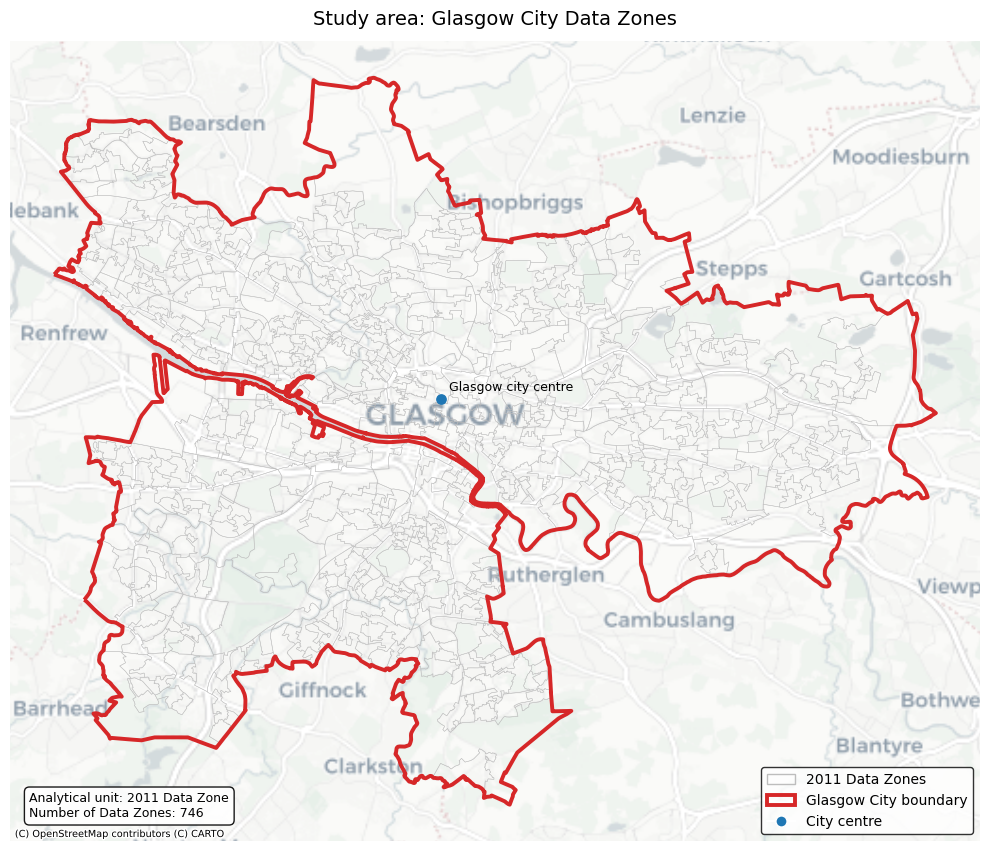

In [6]:
# Plot Glasgow study area with basemap and city centre marker

# Reproject to Web Mercator for basemap
dz_glasgow_3857 = dz_glasgow.to_crs(epsg=3857)
glasgow_boundary_3857 = glasgow_boundary.to_crs(epsg=3857)

# Approximate Glasgow city centre point for orientation only
city_centre = gpd.GeoDataFrame(
    {"place": ["Glasgow city centre"]},
    geometry=gpd.points_from_xy([-4.2518], [55.8642]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

# Plot Data Zone boundaries only, so basemap labels remain visible
dz_glasgow_3857.plot(
    ax=ax,
    facecolor="none",
    edgecolor="#BDBDBD",
    linewidth=0.35,
    alpha=0.85
)

# Emphasise Glasgow City boundary
glasgow_boundary_3857.boundary.plot(
    ax=ax,
    edgecolor="#D62728",
    linewidth=2.8
)

# Add city centre marker
city_centre.plot(
    ax=ax,
    color="#1F77B4",
    markersize=45,
    zorder=5
)

# Add label for city centre
for _, row in city_centre.iterrows():
    ax.annotate(
        row["place"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

# Add basemap
cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.Positron,
    attribution_size=7
)

# Legend
legend_elements = [
    Patch(facecolor="none", edgecolor="#BDBDBD", label="2011 Data Zones"),
    Patch(facecolor="none", edgecolor="#D62728", linewidth=2.8, label="Glasgow City boundary"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#1F77B4",
           markersize=8, label="City centre")
]

ax.legend(
    handles=legend_elements,
    loc="lower right",
    frameon=True,
    facecolor="white",
    edgecolor="black"
)

# Add analytical unit note
ax.text(
    0.02,
    0.03,
    f"Analytical unit: 2011 Data Zone\nNumber of Data Zones: {len(dz_glasgow)}",
    transform=ax.transAxes,
    fontsize=9,
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        alpha=0.9,
        boxstyle="round,pad=0.4"
    )
)

ax.set_title("Study area: Glasgow City Data Zones", fontsize=14, pad=12)
ax.set_axis_off()

plt.tight_layout()
plt.show()

### 2.2 Data Sources

This study used five datasets. First, spatial boundary data were obtained from the 2011 Data Zone boundaries published by SpatialData.gov.scot. Second, vacant and derelict land data were obtained from Spatial Hub Scotland's "Vacant and Derelict Land - Scotland" dataset. Third, deprivation data were taken from SIMD 2020v2. Fourth, car availability and age data were obtained from Scotland's Census 2022. Fifth, distance to River Clyde data were obtained from OS Open Rivers.

| Dimension | Variable | Measurement | Source | Role in analysis |
|---|---|---|---|---|
| **Spatial unit** | Data Zone | 2011 Data Zone polygons within Glasgow City | SpatialData.gov.scot, Data Zone Boundaries 2011; SIMD 2020v2 | Defines the neighbourhood-level spatial unit and Glasgow study boundary |
| **VDL source** | Vacant and derelict land polygons | Polygon features classified as Derelict, Vacant Land, or Vacant Land and Buildings | Spatial Hub Scotland, Vacant and Derelict Land - Scotland | Raw land-use dataset used to construct VDL exposure |
| **Socioeconomic**| Income deprivation score | Reversed SIMD 2020v2 income-domain rank, so higher values indicate greater income deprivation | SIMD 2020v2 | Main explanatory variable: Tests whether VDL exposure is associated with neighbourhood income deprivation |
| **Socioeconomic** | No-car household share | Households with no car or van divided by all occupied households | Scotland's Census 2022 | Socioeconomic control: Captures mobility disadvantage and potential dependence on the local neighbourhood environment |
| **Demographic** | Children share | Population aged 0-17 divided by total population | Scotland's Census 2022, Age | Demographic control: Controls for the share of younger residents who may be more vulnerable to local environmental burdens |
| **Demographic** | Age 65+ share | Population aged 65+ divided by total population | Scotland's Census 2022, Age | Demographic control: Controls for the share of older residents who may be more vulnerable to local environmental burdens |
| **Urban structure** | Population density | Total population divided by Data Zone area | Scotland’s Census 2022; Data Zone boundaries | Urban-structure control: Controls for residential density and broader urban form |
| **Urban structure** | Distance to city centre | Euclidean distance from Data Zone centroid to Glasgow city centre | Data Zone boundaries; derived city-centre coordinate | Urban-structure control: Controls for central–peripheral urban structure |
| **Urban structure** | Distance to River Clyde | Euclidean distance from Data Zone centroid to the River Clyde | OS Open Rivers; Data Zone centroids | Urban-structure control: Captures proximity to a major urban corridor as an exploratory urban-structure variable |


### 2.3 Variable Construction

The main outcome variable measures Data Zone-level exposure to vacant and derelict land (VDL) within a 500m neighbourhood buffer. VDL polygons were first clipped to the Glasgow City boundary, and the clipped area of each polygon was calculated. VDL area and site counts within Data Zones were calculated for descriptive purposes, while the main modelling outcome was based on VDL area within 500m of each Data Zone centroid.

To measure neighbourhood-level exposure, a 500m buffer was constructed around each Data Zone centroid. The total area of VDL polygons intersecting each buffer was calculated in hectares, producing the main exposure variable, **vdl_area_500m_ha**. Because this variable was right-skewed and included zero values, it was transformed as **log(1 + vdl_area_500m_ha)**. The log-transformed variable was used as the main dependent variable in the spatial regression models.

The explanatory and control variables were constructed as rates, densities or distances. The SIMD income rank was reversed to create **income_dep_score**, where higher values indicate greater income deprivation. **no_car_share** was calculated as households with no car or van divided by all occupied households. **child_share** and **older_share** were calculated as age-group populations divided by total population. **pop_density** was calculated as total population divided by Data Zone area and was then transformed into **log_pop_density**. **dist_centre_km** and **dist_clyde_km** were calculated as Euclidean distances from Data Zone centroids.

In [7]:
# Prepare vacant and derelict land polygons for Glasgow

vdl = vdl.to_crs(epsg=27700)
dz_glasgow = dz_glasgow.to_crs(epsg=27700)
glasgow_boundary = glasgow_boundary.to_crs(epsg=27700)

# Attribute-based Glasgow subset, used only as a reference check
vdl_glasgow_attr = vdl[
    vdl["local_auth"] == "Glasgow City"
].copy()

# Spatially clip VDL polygons to the Glasgow Data Zone boundary
vdl_glasgow = gpd.overlay(
    vdl,
    glasgow_boundary[["geometry"]],
    how="intersection"
)

# Calculate geometry-based area after clipping
vdl_glasgow["vdl_area_m2"] = vdl_glasgow.geometry.area
vdl_glasgow["vdl_area_ha"] = vdl_glasgow["vdl_area_m2"] / 10000

# Clean key text fields for later grouping
vdl_glasgow["site_type"] = vdl_glasgow["site_type"].astype(str).str.strip()
vdl_glasgow["local_auth"] = vdl_glasgow["local_auth"].astype(str).str.strip()

print("VDL sites in Glasgow by local_auth field:", vdl_glasgow_attr.shape)
print("VDL polygons after spatial clipping:", vdl_glasgow.shape)
print("Total clipped VDL area (ha):", round(vdl_glasgow["vdl_area_ha"].sum(), 2))

display(
    vdl_glasgow[
        [
            "local_auth",
            "site_name",
            "site_code",
            "datazone",
            "site_type",
            "site_size",
            "vdl_area_ha"
        ]
    ].head()
)

VDL sites in Glasgow by local_auth field: (574, 19)
VDL polygons after spatial clipping: (577, 21)
Total clipped VDL area (ha): 779.93


,local_auth,site_name,site_code,datazone,site_type,site_size,vdl_area_ha
0,Glasgow City,NaN,1300,S01009833,Vacant Land,0.94,0.942537
1,Glasgow City,NaN,1682,S01010046,Vacant Land,0.35,0.346050
2,Glasgow City,NaN,1316,S01009848,Derelict,0.21,0.210488
3,East Renfrewshire,FORMER DEPOT,8511603,S01008317,Derelict,1.7,0.003399
4,East Renfrewshire,RUBBER PLANT,8511615,S01008416,Derelict,1.73,0.008906


In [8]:
# Construct Data Zone-level VDL area within each Data Zone

vdl_by_dz = gpd.overlay(
    vdl_glasgow[
        [
            "site_code",
            "site_type",
            "geometry"
        ]
    ],
    dz_glasgow[
        [
            "DataZone",
            "Name",
            "geometry"
        ]
    ],
    how="intersection"
)

vdl_by_dz["vdl_intersect_area_m2"] = vdl_by_dz.geometry.area
vdl_by_dz["vdl_intersect_area_ha"] = vdl_by_dz["vdl_intersect_area_m2"] / 10000

vdl_dz_summary = (
    vdl_by_dz
    .groupby("DataZone")
    .agg(
        vdl_area_in_dz_ha=("vdl_intersect_area_ha", "sum"),
        vdl_site_count_in_dz=("site_code", "nunique")
    )
    .reset_index()
)

dz_glasgow_vdl = dz_glasgow.merge(
    vdl_dz_summary,
    on="DataZone",
    how="left"
)

dz_glasgow_vdl["vdl_area_in_dz_ha"] = dz_glasgow_vdl["vdl_area_in_dz_ha"].fillna(0)
dz_glasgow_vdl["vdl_site_count_in_dz"] = dz_glasgow_vdl["vdl_site_count_in_dz"].fillna(0).astype(int)

dz_glasgow_vdl["vdl_area_share_pct"] = (
    dz_glasgow_vdl["vdl_area_in_dz_ha"] / dz_glasgow_vdl["StdAreaHa"] * 100
)

print("Data Zones with VDL area:", (dz_glasgow_vdl["vdl_area_in_dz_ha"] > 0).sum())
print("Total VDL area assigned to Data Zones (ha):", round(dz_glasgow_vdl["vdl_area_in_dz_ha"].sum(), 2))

display(
    dz_glasgow_vdl[
        [
            "DataZone",
            "Name",
            "vdl_area_in_dz_ha",
            "vdl_site_count_in_dz",
            "vdl_area_share_pct"
        ]
    ].head()
)

Data Zones with VDL area: 285
Total VDL area assigned to Data Zones (ha): 779.93


,DataZone,Name,vdl_area_in_dz_ha,vdl_site_count_in_dz,vdl_area_share_pct
0,S01009758,Darnley East - 01,0.000000,0,0.000000
1,S01009759,Darnley East - 02,0.919004,1,6.752842
2,S01009760,Darnley East - 03,2.605173,3,7.838759
3,S01009761,Darnley East - 04,0.000000,0,0.000000
4,S01009762,Darnley East - 05,0.000656,1,0.004352


In [9]:
# Construct 500m neighbourhood exposure to vacant and derelict land

BUFFER_DISTANCE_M = 500

# Use Data Zone centroids for consistency with distance-based variables
dz_points = dz_glasgow_vdl[
    [
        "DataZone",
        "Name",
        "geometry"
    ]
].copy()

dz_points["geometry"] = dz_points.geometry.centroid

dz_buffers_500m = dz_points.copy()
dz_buffers_500m["geometry"] = dz_buffers_500m.geometry.buffer(BUFFER_DISTANCE_M)

# Use VDL within Glasgow boundary + 500m buffer to avoid boundary truncation
glasgow_boundary_buffer_500m = glasgow_boundary.copy()
glasgow_boundary_buffer_500m["geometry"] = glasgow_boundary_buffer_500m.geometry.buffer(BUFFER_DISTANCE_M)

vdl_for_buffer = gpd.overlay(
    vdl,
    glasgow_boundary_buffer_500m[["geometry"]],
    how="intersection"
)

vdl_buffer_intersections = gpd.overlay(
    dz_buffers_500m,
    vdl_for_buffer[
        [
            "site_code",
            "site_type",
            "geometry"
        ]
    ],
    how="intersection"
)

vdl_buffer_intersections["vdl_buffer_area_m2"] = vdl_buffer_intersections.geometry.area
vdl_buffer_intersections["vdl_buffer_area_ha"] = (
    vdl_buffer_intersections["vdl_buffer_area_m2"] / 10000
)

vdl_buffer_summary = (
    vdl_buffer_intersections
    .groupby("DataZone")
    .agg(
        vdl_area_500m_ha=("vdl_buffer_area_ha", "sum"),
        vdl_site_count_500m=("site_code", "nunique")
    )
    .reset_index()
)

analysis_gdf = dz_glasgow_vdl.merge(
    vdl_buffer_summary,
    on="DataZone",
    how="left"
)

analysis_gdf["vdl_area_500m_ha"] = analysis_gdf["vdl_area_500m_ha"].fillna(0)
analysis_gdf["vdl_site_count_500m"] = (
    analysis_gdf["vdl_site_count_500m"]
    .fillna(0)
    .astype(int)
)

print("VDL polygons used for 500m buffer exposure:", vdl_for_buffer.shape[0])
print("Data Zones with VDL exposure within 500m:", (analysis_gdf["vdl_area_500m_ha"] > 0).sum())
print("Total Data Zones:", len(analysis_gdf))
print("Maximum VDL area within 500m (ha):", round(analysis_gdf["vdl_area_500m_ha"].max(), 2))

display(
    analysis_gdf[
        [
            "DataZone",
            "Name",
            "vdl_area_in_dz_ha",
            "vdl_site_count_in_dz",
            "vdl_area_500m_ha",
            "vdl_site_count_500m"
        ]
    ].head()
)

VDL polygons used for 500m buffer exposure: 653
Data Zones with VDL exposure within 500m: 556
Total Data Zones: 746
Maximum VDL area within 500m (ha): 28.55


,DataZone,Name,vdl_area_in_dz_ha,vdl_site_count_in_dz,vdl_area_500m_ha,vdl_site_count_500m
0,S01009758,Darnley East - 01,0.000000,0,0.137974,1
1,S01009759,Darnley East - 02,0.919004,1,2.369184,2
2,S01009760,Darnley East - 03,2.605173,3,4.261264,3
3,S01009761,Darnley East - 04,0.000000,0,2.929596,2
4,S01009762,Darnley East - 05,0.000656,1,2.598698,2


,vdl_area_500m_ha
count,746.000
mean,2.961
std,4.364
min,0.000
25%,0.000
50%,0.970
75%,4.114
max,28.550


,log_vdl_area_500m
count,746.000
mean,0.923
std,0.907
min,0.000
25%,0.000
50%,0.678
75%,1.632
max,3.386


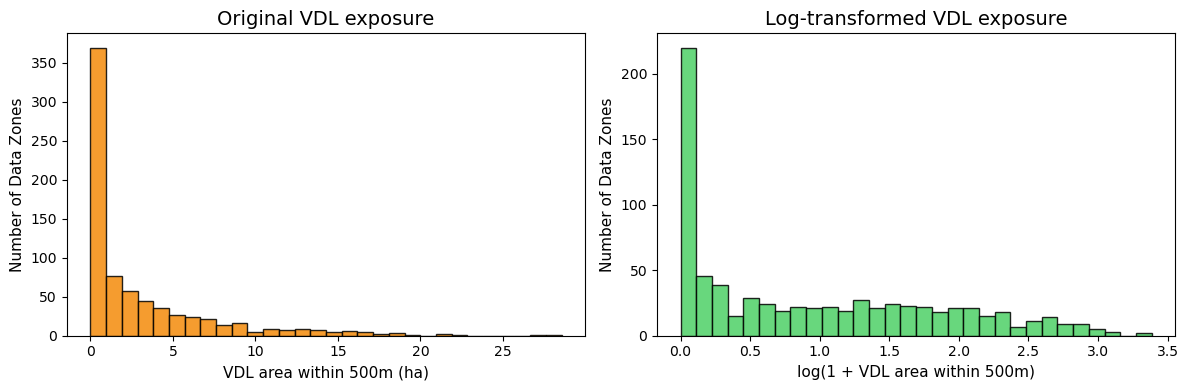

In [10]:
# Summarise and transform VDL exposure outcome

vdl_exposure_summary_before = (
    analysis_gdf["vdl_area_500m_ha"]
    .describe()
    .round(3)
)

display(
    vdl_exposure_summary_before
    .rename("vdl_area_500m_ha")
    .to_frame()
)

analysis_gdf["log_vdl_area_500m"] = np.log1p(
    analysis_gdf["vdl_area_500m_ha"]
)

vdl_exposure_summary_after = (
    analysis_gdf["log_vdl_area_500m"]
    .describe()
    .round(3)
)

display(
    vdl_exposure_summary_after
    .rename("log_vdl_area_500m")
    .to_frame()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    analysis_gdf["vdl_area_500m_ha"],
    bins=30,
    color="#F48B0A",
    edgecolor="black",
    alpha=0.85
)
axes[0].set_title("Original VDL exposure")
axes[0].set_xlabel("VDL area within 500m (ha)")
axes[0].set_ylabel("Number of Data Zones")

axes[1].hist(
    analysis_gdf["log_vdl_area_500m"],
    bins=30,
    color="#4DD166",
    edgecolor="black",
    alpha=0.85
)
axes[1].set_title("Log-transformed VDL exposure")
axes[1].set_xlabel("log(1 + VDL area within 500m)")
axes[1].set_ylabel("Number of Data Zones")

plt.tight_layout()
plt.show()

In [11]:
# Construct no-car household share from Census car availability data

car_raw = pd.read_csv(
    car_file,
    skiprows=10,
    header=0
)

car_raw = car_raw.dropna(axis=1, how="all")

car_vars = car_raw.rename(columns={
    "Number of cars or vans": "DataZone",
    "All occupied households": "all_households",
    "Number of cars or vans in household: No cars or vans": "no_car_households"
}).copy()

car_vars = car_vars[
    car_vars["DataZone"].astype(str).str.startswith("S010")
].copy()

car_vars = car_vars[
    [
        "DataZone",
        "all_households",
        "no_car_households"
    ]
].copy()

car_vars["all_households"] = pd.to_numeric(
    car_vars["all_households"],
    errors="coerce"
)

car_vars["no_car_households"] = pd.to_numeric(
    car_vars["no_car_households"],
    errors="coerce"
)

car_vars["no_car_share"] = (
    car_vars["no_car_households"] / car_vars["all_households"]
)

print("Car variables:", car_vars.shape)
print("Missing values:")
print(car_vars.isna().sum())

display(
    car_vars[
        ["no_car_share"]
    ].describe().round(3)
)

Car variables: (6976, 4)
Missing values:
DataZone             0
all_households       0
no_car_households    0
no_car_share         4
dtype: int64


,no_car_share
count,6972.000
mean,0.252
std,0.161
min,0.000
25%,0.115
50%,0.228
75%,0.356
max,0.822


In [12]:
# Construct age structure variables from Census age data

import re

age_records = []

with open(age_file, "r", encoding="utf-8-sig", newline="") as f:
    reader = csv.reader(f)
    rows = list(reader)

current_datazone = None
current_total_population = None
children_0_17 = 0
older_65_plus = 0

def save_current_record():
    if current_datazone is not None:
        age_records.append({
            "DataZone": current_datazone,
            "total_population_age": current_total_population,
            "children_0_17": children_0_17,
            "older_65_plus": older_65_plus
        })

for row in rows:
    if len(row) == 0:
        continue

    first_col = str(row[0]).strip()

    # Identify true Data Zone codes only, e.g. S01006506
    if re.match(r"^S\d{8}$", first_col):
        save_current_record()

        current_datazone = first_col
        current_total_population = None
        children_0_17 = 0
        older_65_plus = 0
        continue

    # Skip rows before the first true Data Zone
    if current_datazone is None:
        continue

    if len(row) < 2:
        continue

    age_label = first_col
    all_people = pd.to_numeric(row[1], errors="coerce")

    if pd.isna(all_people):
        continue

    # Total population row
    if age_label == "All people":
        current_total_population = all_people

    # Children: 0–17
    elif age_label in ["0 - 4", "5 - 9", "10 - 14", "15", "16 - 17"]:
        children_0_17 += all_people

    # Older population: 65+
    elif age_label in [
        "65 - 69",
        "70 - 74",
        "75 - 79",
        "80 - 84",
        "85 and over"
    ]:
        older_65_plus += all_people

# Save final Data Zone block
save_current_record()

age_vars = pd.DataFrame(age_records)

age_vars["child_share"] = age_vars["children_0_17"] / age_vars["total_population_age"]
age_vars["older_share"] = age_vars["older_65_plus"] / age_vars["total_population_age"]

print("Age variables:", age_vars.shape)

print("\nMissing values:")
print(age_vars.isna().sum())

print("\nAge share summary:")
display(
    age_vars[
        [
            "child_share",
            "older_share"
        ]
    ]
    .describe()
    .round(3)
)

Age variables: (6976, 6)

Missing values:
DataZone                0
total_population_age    0
children_0_17           0
older_65_plus           0
child_share             4
older_share             4
dtype: int64

Age share summary:


,child_share,older_share
count,6972.000,6972.000
mean,0.182,0.209
std,0.053,0.085
min,0.000,0.007
25%,0.148,0.151
50%,0.180,0.206
75%,0.215,0.265
max,0.466,0.786


In [13]:
# Join Census explanatory variables to Glasgow analysis dataset

analysis_gdf = analysis_gdf.merge(
    car_vars[
        [
            "DataZone",
            "all_households",
            "no_car_households",
            "no_car_share"
        ]
    ],
    on="DataZone",
    how="left"
)

analysis_gdf = analysis_gdf.merge(
    age_vars[
        [
            "DataZone",
            "total_population_age",
            "children_0_17",
            "older_65_plus",
            "child_share",
            "older_share"
        ]
    ],
    on="DataZone",
    how="left"
)

census_vars = [
    "no_car_share",
    "child_share",
    "older_share"
]

print("Analysis dataset after joining Census variables:", analysis_gdf.shape)

print("\nMissing values in Glasgow:")
print(
    analysis_gdf[census_vars]
    .isna()
    .sum()
)

display(
    analysis_gdf[census_vars]
    .describe()
    .round(3)
)

Analysis dataset after joining Census variables: (746, 29)

Missing values in Glasgow:
no_car_share    3
child_share     3
older_share     3
dtype: int64


,no_car_share,child_share,older_share
count,743.000,743.000,743.000
mean,0.423,0.175,0.147
std,0.166,0.064,0.069
min,0.020,0.013,0.008
25%,0.309,0.132,0.094
50%,0.446,0.179,0.140
75%,0.550,0.219,0.195
max,0.822,0.380,0.407


,pop_density,dist_centre_km
count,746.000,746.000
mean,7072.539,4.920
std,5501.139,2.243
min,0.000,0.293
25%,3708.219,3.133
50%,5509.702,4.732
75%,8529.023,6.604
max,40596.758,10.297


,log_pop_density,dist_centre_km
count,746.000,746.000
mean,8.563,4.920
std,0.954,2.243
min,0.000,0.293
25%,8.219,3.133
50%,8.614,4.732
75%,9.051,6.604
max,10.611,10.297


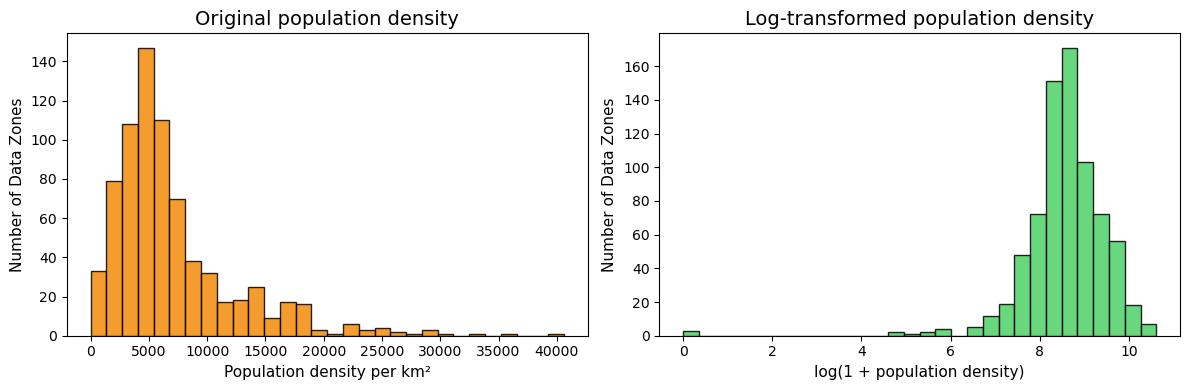

In [14]:
# Construct population density and distance to city centre

# Population density from Census total population and Data Zone area
analysis_gdf["pop_density"] = (
    analysis_gdf["total_population_age"] / analysis_gdf["StdAreaKm2"]
)

# Distance to Glasgow city centre
# Approximate city centre reference point: George Square, British National Grid
glasgow_centre_x = 259000
glasgow_centre_y = 665600

analysis_gdf["centroid"] = analysis_gdf.geometry.centroid

analysis_gdf["dist_centre_km"] = (
    analysis_gdf["centroid"].distance(
        Point(glasgow_centre_x, glasgow_centre_y)
    ) / 1000
)

# Summarise before transformation
urban_structure_summary_before = analysis_gdf[
    [
        "pop_density",
        "dist_centre_km"
    ]
].describe().round(3)

display(urban_structure_summary_before)

# Log-transform population density
analysis_gdf["log_pop_density"] = np.log1p(
    analysis_gdf["pop_density"]
)

urban_structure_summary_after = analysis_gdf[
    [
        "log_pop_density",
        "dist_centre_km"
    ]
].describe().round(3)

display(urban_structure_summary_after)

# Compare original and log-transformed population density distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    analysis_gdf["pop_density"],
    bins=30,
    color="#F48B0A",
    edgecolor="black",
    alpha=0.85
)
axes[0].set_title("Original population density")
axes[0].set_xlabel("Population density per km²")
axes[0].set_ylabel("Number of Data Zones")

axes[1].hist(
    analysis_gdf["log_pop_density"],
    bins=30,
    color="#4DD166",
    edgecolor="black",
    alpha=0.85
)
axes[1].set_title("Log-transformed population density")
axes[1].set_xlabel("log(1 + population density)")
axes[1].set_ylabel("Number of Data Zones")

plt.tight_layout()
plt.show()

River Clyde segments near Glasgow: 37


,dist_clyde_km
count,746.000
mean,2.522
std,1.547
min,0.121
25%,1.326
50%,2.337
75%,3.436
max,7.512


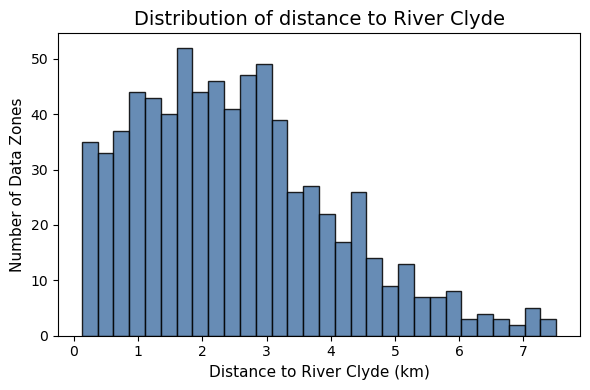

In [15]:
# Construct distance to River Clyde from OS Open Rivers

rivers_file = RAW_DIR / "OS_Open_Rivers" / "Data" / "oprvrs_gb.gpkg"

rivers = gpd.read_file(
    rivers_file,
    layer="watercourse_link"
).to_crs(epsg=27700)

# Use Glasgow study boundary to reduce processing load
glasgow_boundary_for_rivers = analysis_gdf.dissolve().reset_index(drop=True)

glasgow_buffer_10km = glasgow_boundary_for_rivers.copy()
glasgow_buffer_10km["geometry"] = glasgow_buffer_10km.geometry.buffer(10000)

rivers_near_glasgow = gpd.overlay(
    rivers,
    glasgow_buffer_10km[["geometry"]],
    how="intersection"
)

# Select River Clyde segments
river_clyde = rivers_near_glasgow[
    rivers_near_glasgow["watercourse_name"] == "River Clyde"
].copy()

if river_clyde.empty:
    raise ValueError("No River Clyde segments found in OS Open Rivers.")

# Merge River Clyde geometries into one geometry
try:
    clyde_union = river_clyde.geometry.union_all()
except AttributeError:
    clyde_union = river_clyde.geometry.unary_union

# Use Data Zone centroids for consistency with other distance variables
analysis_gdf["centroid"] = analysis_gdf.geometry.centroid

analysis_gdf["dist_clyde_km"] = (
    analysis_gdf["centroid"].distance(clyde_union) / 1000
)

print("River Clyde segments near Glasgow:", river_clyde.shape[0])

display(
    analysis_gdf["dist_clyde_km"]
    .describe()
    .round(3)
    .rename("dist_clyde_km")
    .to_frame()
)

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(
    analysis_gdf["dist_clyde_km"],
    bins=30,
    color="#4C78A8",
    edgecolor="black",
    alpha=0.85
)

ax.set_title("Distribution of distance to River Clyde")
ax.set_xlabel("Distance to River Clyde (km)")
ax.set_ylabel("Number of Data Zones")

plt.tight_layout()
plt.show()

In [16]:
# Create final modelling dataset

target_var = "log_vdl_area_500m"

income_rank_col = "SIMD2020v2_Income_Domain_Rank"

# Convert income rank so that higher values indicate greater income deprivation
# In SIMD, lower rank means more deprived. This transformation reverses the direction.
max_income_rank = analysis_gdf[income_rank_col].max()

analysis_gdf["income_dep_score"] = (
    max_income_rank + 1 - analysis_gdf[income_rank_col]
)

features_raw = [
    "income_dep_score",
    "no_car_share",
    "child_share",
    "older_share",
    "log_pop_density",
    "dist_centre_km",
    "dist_clyde_km"
]

model_vars = [
    "DataZone",
    "Name",
    target_var,
    "vdl_area_500m_ha",
    "vdl_site_count_500m",
    "vdl_area_in_dz_ha",
    "vdl_site_count_in_dz"
] + features_raw + ["geometry"]

model_gdf = analysis_gdf[model_vars].copy()

print("Initial modelling dataset:", model_gdf.shape)

print("\nMissing values before dropping incomplete rows:")
print(
    model_gdf[
        [target_var] + features_raw
    ].isna().sum()
)

model_gdf = model_gdf.dropna(
    subset=[target_var] + features_raw
).copy()

print("\nFinal modelling dataset:", model_gdf.shape)

display(
    model_gdf[
        [
            target_var,
            "vdl_area_500m_ha",
            "income_dep_score",
            "no_car_share",
            "child_share",
            "older_share",
            "log_pop_density",
            "dist_centre_km",
            "dist_clyde_km"
        ]
    ].describe().round(3)
)

Initial modelling dataset: (746, 15)

Missing values before dropping incomplete rows:
log_vdl_area_500m    0
income_dep_score     0
no_car_share         3
child_share          3
older_share          3
log_pop_density      0
dist_centre_km       0
dist_clyde_km        0
dtype: int64

Final modelling dataset: (743, 15)


,log_vdl_area_500m,vdl_area_500m_ha,income_dep_score,no_car_share,child_share,older_share,log_pop_density,dist_centre_km,dist_clyde_km
count,743.000,743.000,743.000,743.000,743.000,743.000,743.000,743.000,743.000
mean,0.917,2.924,4778.801,0.423,0.175,0.147,8.598,4.931,2.521
std,0.904,4.314,1951.392,0.166,0.064,0.069,0.785,2.239,1.550
min,0.000,0.000,6.000,0.020,0.013,0.008,4.780,0.293,0.121
25%,0.000,0.000,3274.500,0.309,0.132,0.094,8.226,3.144,1.323
50%,0.673,0.960,5426.000,0.446,0.179,0.140,8.621,4.749,2.338
75%,1.621,4.060,6494.500,0.550,0.219,0.195,9.054,6.619,3.435
max,3.386,28.550,6969.000,0.822,0.380,0.407,10.611,10.297,7.512


### 2.4 Data Cleaning

In [17]:
# Create data cleaning audit table

cleaning_audit = pd.DataFrame({
    "Processing step": [
        "National Data Zones loaded",
        "Glasgow Data Zones selected",
        "VDL polygons clipped to Glasgow boundary",
        "Census car availability joined",
        "Census age variables joined",
        "Final modelling dataset created"
    ],
    "Input records": [
        len(dz),
        len(dz),
        len(vdl),
        len(analysis_gdf),
        len(analysis_gdf),
        len(analysis_gdf)
    ],
    "Output records": [
        len(dz),
        len(dz_glasgow),
        len(vdl_glasgow),
        analysis_gdf["no_car_share"].notna().sum(),
        analysis_gdf[["child_share", "older_share"]].dropna().shape[0],
        len(model_gdf)
    ],
    "Records removed / missing": [
        0,
        len(dz) - len(dz_glasgow),
        len(vdl) - len(vdl_glasgow),
        analysis_gdf["no_car_share"].isna().sum(),
        analysis_gdf[["child_share", "older_share"]].isna().any(axis=1).sum(),
        len(analysis_gdf) - len(model_gdf)
    ],
    "Reason": [
        "Original national boundary dataset",
        "Filtered to Glasgow City Data Zones",
        "Spatially clipped to Glasgow City boundary",
        "Missing or unmatched Census car availability records",
        "Missing or unmatched Census age records",
        "Rows with missing modelling variables removed"
    ]
})

# Display full data cleaning audit table

with pd.option_context("display.max_colwidth", None):
    display(cleaning_audit)

,Processing step,Input records,Output records,Records removed / missing,Reason
0,National Data Zones loaded,6976,6976,0,Original national boundary dataset
1,Glasgow Data Zones selected,6976,746,6230,Filtered to Glasgow City Data Zones
2,VDL polygons clipped to Glasgow boundary,3154,577,2577,Spatially clipped to Glasgow City boundary
3,Census car availability joined,746,743,3,Missing or unmatched Census car availability records
4,Census age variables joined,746,743,3,Missing or unmatched Census age records
5,Final modelling dataset created,746,743,3,Rows with missing modelling variables removed


After filtering the national boundary dataset, 746 Glasgow Data Zones were retained. VDL polygons were spatially clipped to the Glasgow City boundary, resulting in 577 clipped VDL polygons. Census-derived variables were then joined to the Data Zone dataset.

Three Data Zones were excluded from the final modelling dataset because they had missing or undefined Census-derived car availability and age variables. These excluded Data Zones were checked spatially and did not form a large contiguous missing-data cluster. The final modelling dataset contained 743 Data Zones.

Data Zones with no intersecting VDL polygon within the Data Zone or 500m buffer were assigned zero exposure, as this indicates no observed VDL within the specified spatial extent rather than missing data. Other missing values in explanatory variables were not imputed and the three affected Data Zones were removed from the modelling dataset.

Excluded Data Zones: 3


,DataZone,Name,vdl_area_500m_ha,log_vdl_area_500m,income_dep_score,no_car_share,child_share,older_share,log_pop_density,dist_centre_km,dist_clyde_km
448,S01010206,Petershill - 04,21.376159,3.107996,1.0,NaN,NaN,NaN,0.0,3.464989,3.877826
468,S01010226,Sighthill - 02,7.337742,2.120792,1.0,NaN,NaN,NaN,0.0,1.625597,2.294378
469,S01010227,Sighthill - 03,7.410164,2.129441,1.0,NaN,NaN,NaN,0.0,1.403216,2.096080


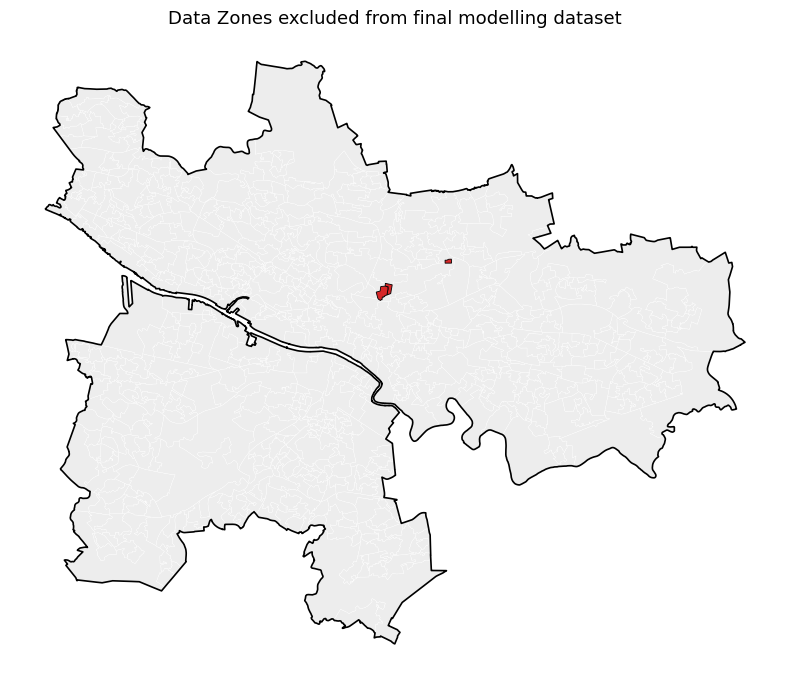

In [18]:
# Check excluded Data Zones from final modelling dataset

model_datazones = set(model_gdf["DataZone"])
all_datazones = set(analysis_gdf["DataZone"])

excluded_datazones = sorted(all_datazones - model_datazones)

excluded_gdf = analysis_gdf[
    analysis_gdf["DataZone"].isin(excluded_datazones)
].copy()

print("Excluded Data Zones:", len(excluded_gdf))

missing_check_cols = [
    "DataZone",
    "Name",
    "vdl_area_500m_ha",
    "log_vdl_area_500m",
    "income_dep_score",
    "no_car_share",
    "child_share",
    "older_share",
    "log_pop_density",
    "dist_centre_km",
    "dist_clyde_km"
]

display(
    excluded_gdf[
        [col for col in missing_check_cols if col in excluded_gdf.columns]
    ]
)

# Map excluded Data Zones to check whether missingness is spatially concentrated
fig, ax = plt.subplots(figsize=(8, 8))

analysis_gdf.plot(
    ax=ax,
    facecolor="#EDEDED",
    edgecolor="white",
    linewidth=0.25
)

if len(excluded_gdf) > 0:
    excluded_gdf.plot(
        ax=ax,
        facecolor="#D62728",
        edgecolor="black",
        linewidth=0.6,
        label="Excluded Data Zones"
    )

glasgow_boundary.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1.2
)

ax.set_title("Data Zones excluded from final modelling dataset", fontsize=13)
ax.set_axis_off()

plt.tight_layout()
plt.show()

## 3. Methodology

The analysis followed a spatial quantitative workflow designed to examine both the spatial pattern of VDL exposure and its association with neighbourhood characteristics. The methods were organised into four stages: **descriptive spatial analysis**, **spatial regression**, **machine learning** interpretation, and **robustness checks**.

First, descriptive spatial analysis was used to understand the distribution of VDL exposure before modelling. Choropleth maps, summary statistics and histograms were used to examine spatial unevenness and the right-skewed distribution of vdl_area_500m_ha. Global Moran's I was then calculated using Queen contiguity weights to test whether VDL exposure was spatially clustered rather than randomly distributed (Moran, 1950). Queen contiguity was selected because the analysis uses Data Zone units and requires a first-order neighbourhood definition that includes polygons sharing either an edge or a vertex (Anselin, 1988; Bivand, Pebesma and Gómez-Rubio, 2013). Local Moran's I was used to identify high-high and low-low clusters, because LISA statistics detect local pockets of spatial association that may be hidden by a global statistic (Anselin, 1995). Permutation-based Moran's I and Local Moran's I tests used 999 permutations with a fixed random seed to ensure reproducibility.

Second, regression models were used to examine which neighbourhood characteristics were associated with VDL exposure. An OLS model was first estimated as a non-spatial baseline, and variance inflation factors were calculated to check whether the explanatory variables were affected by strong multicollinearity. OLS residuals were then tested using Moran's I, because spatially autocorrelated residuals would indicate that a standard regression model violates the assumption of independent errors (Anselin, 1988).
Because the OLS residuals remained spatially autocorrelated, spatial regression models were estimated. Lagrange Multiplier diagnostics were used to guide the choice between spatial lag and spatial error specifications (Anselin et al., 1996). A Spatial Lag Model and a Spatial Error Model were both estimated, and the final model choice was assessed using the LM diagnostics, AIC and residual Moran's I. The Spatial Lag Model was retained because it was supported by the robust LM results, had the lower AIC, and removed residual spatial autocorrelation.

Third, a Random Forest regressor was used to assess whether the relationship between VDL exposure and neighbourhood characteristics contained non-linear predictive patterns that may not be captured by the spatial regression model. Random Forests are suitable for this purpose because they can capture non-linear relationships and interactions without imposing a linear functional form (Breiman, 2001). A minimum leaf size of 5 was set as a regularisation choice to reduce overfitting to very small groups of Data Zones. Model performance was evaluated using a train-test split, random five-fold cross-validation and spatial-block validation, because random cross-validation can overstate performance when nearby observations are spatially dependent (Roberts et al., 2017).

Permutation importance and SHAP values were used to interpret the Random Forest model. Permutation importance assessed how much predictive performance declined when each variable was disrupted, while SHAP values showed how each predictor contributed to model predictions (Lundberg and Lee, 2017). These results were interpreted as model explanations rather than causal effects.

Finally, a robustness check was conducted using derelict-only exposure. This tested whether the spatial pattern of the combined VDL measure was also present when only derelict land was considered.


## 4. Results

### 4.1 Descriptive Statistics and Spatial Patterns

In [19]:
# Descriptive statistics for final modelling variables

descriptive_vars = [
    "vdl_area_500m_ha",
    "log_vdl_area_500m",
    "income_dep_score",
    "no_car_share",
    "child_share",
    "older_share",
    "log_pop_density",
    "dist_centre_km",
    "dist_clyde_km"
]

descriptive_stats = (
    model_gdf[descriptive_vars]
    .describe()
    .T
    .rename(columns={
        "count": "N",
        "mean": "Mean",
        "std": "SD",
        "min": "Min",
        "25%": "25%",
        "50%": "Median",
        "75%": "75%",
        "max": "Max"
    })
    .round(3)
)

display(descriptive_stats)

,N,Mean,SD,Min,25%,Median,75%,Max
vdl_area_500m_ha,743.0,2.924,4.314,0.000,0.000,0.960,4.060,28.550
log_vdl_area_500m,743.0,0.917,0.904,0.000,0.000,0.673,1.621,3.386
income_dep_score,743.0,4778.801,1951.392,6.000,3274.500,5426.000,6494.500,6969.000
no_car_share,743.0,0.423,0.166,0.020,0.309,0.446,0.550,0.822
child_share,743.0,0.175,0.064,0.013,0.132,0.179,0.219,0.380
older_share,743.0,0.147,0.069,0.008,0.094,0.140,0.195,0.407
log_pop_density,743.0,8.598,0.785,4.780,8.226,8.621,9.054,10.611
dist_centre_km,743.0,4.931,2.239,0.293,3.144,4.749,6.619,10.297
dist_clyde_km,743.0,2.521,1.550,0.121,1.323,2.338,3.435,7.512


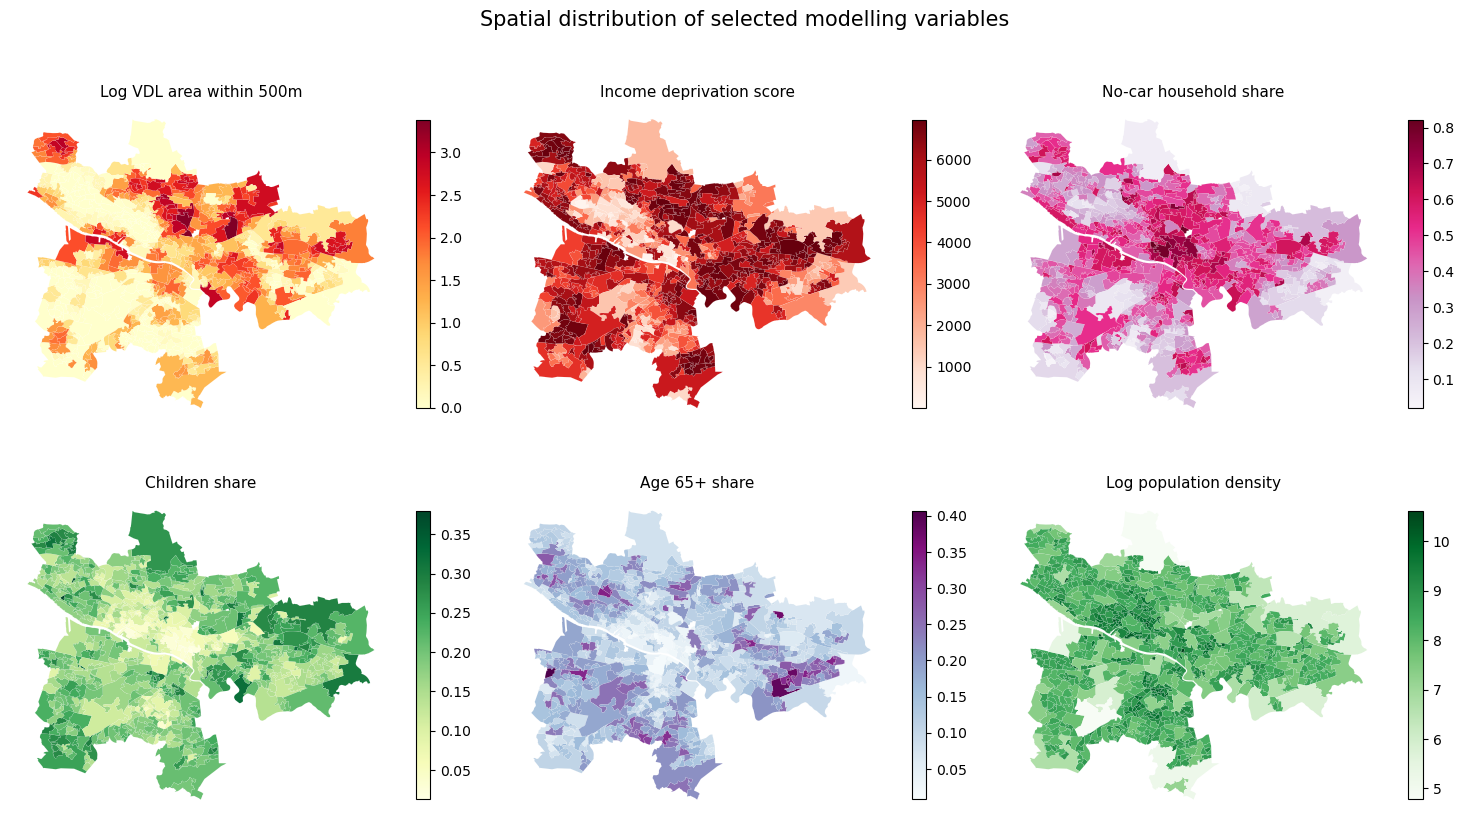

In [20]:
# Spatial distribution of selected modelling variables

map_vars = [
    "log_vdl_area_500m",
    "income_dep_score",
    "no_car_share",
    "child_share",
    "older_share",
    "log_pop_density"
]

map_titles = [
    "Log VDL area within 500m",
    "Income deprivation score",
    "No-car household share",
    "Children share",
    "Age 65+ share",
    "Log population density"
]

map_cmaps = [
    "YlOrRd",
    "Reds",
    "PuRd",
    "YlGn",
    "BuPu",
    "Greens"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, var, title, cmap in zip(axes, map_vars, map_titles, map_cmaps):
    model_gdf.plot(
        column=var,
        ax=ax,
        cmap=cmap,
        linewidth=0.05,
        edgecolor="white",
        legend=True,
        legend_kwds={"shrink": 0.65}
    )
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()

plt.suptitle(
    "Spatial distribution of selected modelling variables",
    fontsize=15,
    y=0.98
)

plt.tight_layout()
plt.show()

In [21]:
# Check composition of vacant and derelict land by site type

vdl_type_summary = (
    vdl_glasgow
    .groupby("site_type")
    .agg(
        n_polygons=("site_code", "count"),
        total_area_ha=("vdl_area_ha", "sum")
    )
    .reset_index()
)

vdl_type_summary["area_share_pct"] = (
    vdl_type_summary["total_area_ha"] / vdl_type_summary["total_area_ha"].sum() * 100
).round(2)

vdl_type_summary["total_area_ha"] = vdl_type_summary["total_area_ha"].round(2)

display(vdl_type_summary)

,site_type,n_polygons,total_area_ha,area_share_pct
0,Derelict,208,440.36,56.46
1,Vacant Land,349,320.78,41.13
2,Vacant Land and Buildings,20,18.79,2.41


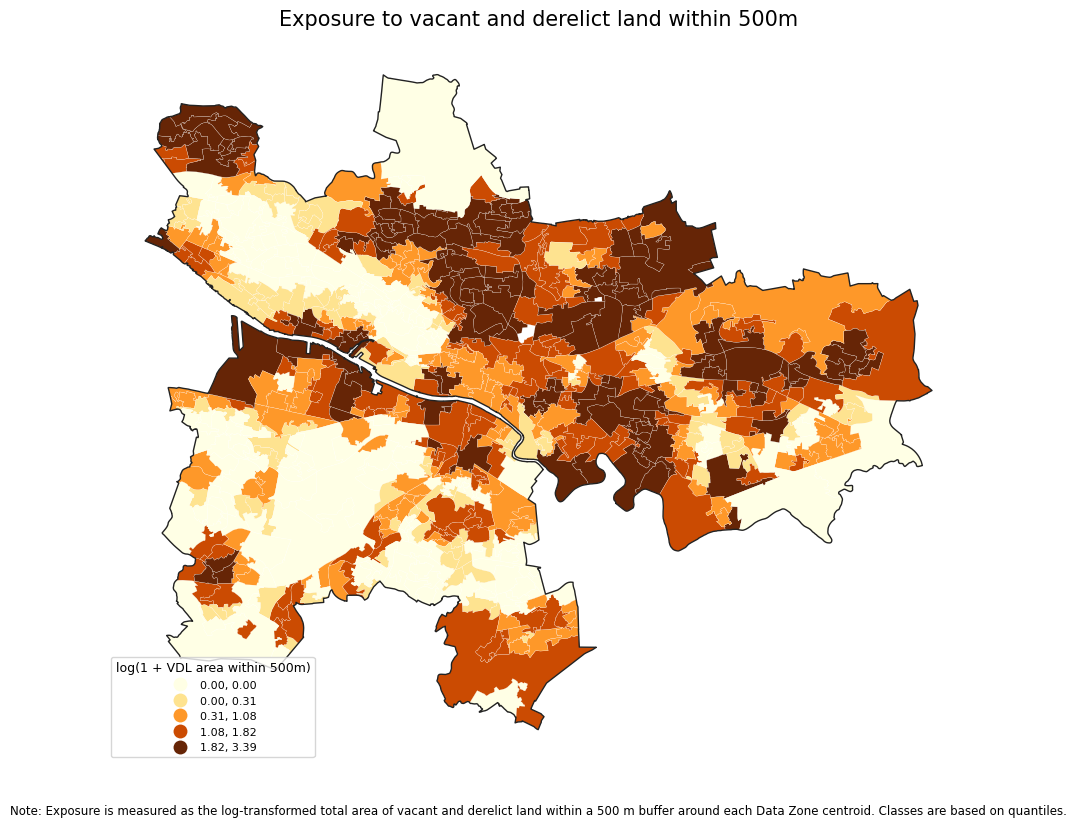

In [22]:
# Map VDL exposure across Glasgow Data Zones

fig, ax = plt.subplots(figsize=(11, 8.8))

model_gdf.plot(
    column="log_vdl_area_500m",
    ax=ax,
    cmap="YlOrBr",
    scheme="quantiles",
    k=5,
    legend=True,
    edgecolor="white",
    linewidth=0.15,
    legend_kwds={
        "title": "log(1 + VDL area within 500m)",
        "loc": "lower left",
        "fontsize": 8,
        "title_fontsize": 9
    }
)

glasgow_boundary.boundary.plot(
    ax=ax,
    color="#222222",
    linewidth=1.0
)

ax.set_title(
    "Exposure to vacant and derelict land within 500m",
    fontsize=15,
    pad=12
)

ax.axis("off")

note = (
    "Note: Exposure is measured as the log-transformed total area of vacant and derelict land "
    "within a 500 m buffer around each Data Zone centroid. "
    "Classes are based on quantiles."
)

fig.text(
    0.5,
    0.025,
    note,
    ha="center",
    va="bottom",
    fontsize=8.5
)

plt.tight_layout(rect=[0.02, 0.07, 0.98, 0.96])
plt.show()

In [23]:
# Construct spatial weights matrix

w = Queen.from_dataframe(model_gdf)
w.transform = "r"

print("Spatial weights matrix: Queen contiguity")
print("Number of observations:", w.n)
print("Mean number of neighbours:", round(w.mean_neighbors, 2))
print("Minimum number of neighbours:", w.min_neighbors)
print("Maximum number of neighbours:", w.max_neighbors)
print("Number of islands:", len(w.islands))

Spatial weights matrix: Queen contiguity
Number of observations: 743
Mean number of neighbours: 5.77
Minimum number of neighbours: 1
Maximum number of neighbours: 18
Number of islands: 0


In [24]:
# Global Moran's I for VDL exposure

vdl_values = model_gdf["log_vdl_area_500m"].values

np.random.seed(RANDOM_SEED)

moran_vdl = Moran(
    vdl_values,
    w,
    permutations=999
)

print("Global Moran's I for VDL exposure")
print("Moran's I:", round(moran_vdl.I, 4))
print("Expected I:", round(moran_vdl.EI, 4))
print("p-value:", round(moran_vdl.p_sim, 4))

Global Moran's I for VDL exposure
Moran's I: 0.6851
Expected I: -0.0013
p-value: 0.001


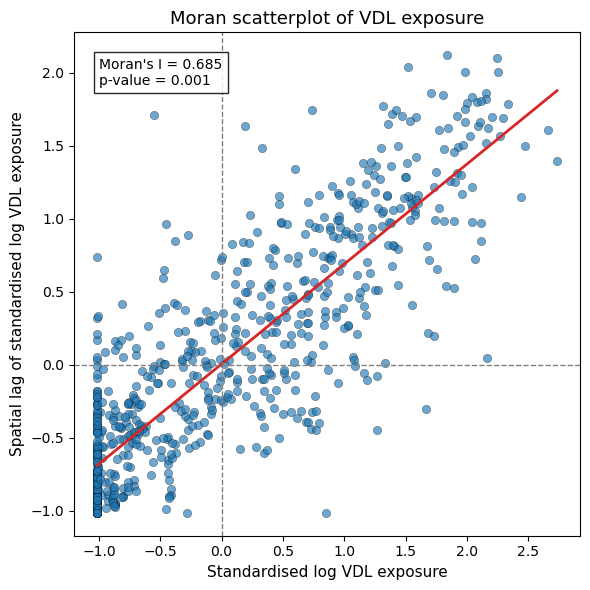

In [25]:
# Moran scatterplot for VDL exposure

from libpysal.weights.spatial_lag import lag_spatial

y = model_gdf["log_vdl_area_500m"].values

# Standardise the variable for Moran scatterplot
y_std = (y - y.mean()) / y.std()

# Spatial lag of standardised VDL exposure
wy_std = lag_spatial(w, y_std)

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    y_std,
    wy_std,
    alpha=0.65,
    edgecolor="black",
    linewidth=0.3
)

# Fitted line
slope, intercept = np.polyfit(y_std, wy_std, 1)
x_vals = np.array([y_std.min(), y_std.max()])
ax.plot(
    x_vals,
    intercept + slope * x_vals,
    color="#D62728",
    linewidth=2
)

# Reference lines
ax.axhline(0, color="grey", linewidth=1, linestyle="--")
ax.axvline(0, color="grey", linewidth=1, linestyle="--")

ax.set_title("Moran scatterplot of VDL exposure", fontsize=13)
ax.set_xlabel("Standardised log VDL exposure")
ax.set_ylabel("Spatial lag of standardised log VDL exposure")

ax.text(
    0.05,
    0.95,
    f"Moran's I = {moran_vdl.I:.3f}\np-value = {moran_vdl.p_sim:.3f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.85)
)

plt.tight_layout()
plt.show()

In [26]:
# Local Moran's I for VDL exposure

np.random.seed(RANDOM_SEED)

lisa_vdl = Moran_Local(
    model_gdf["log_vdl_area_500m"].values,
    w,
    permutations=999
)

model_gdf["vdl_lisa_I"] = lisa_vdl.Is
model_gdf["vdl_lisa_p"] = lisa_vdl.p_sim
model_gdf["vdl_lisa_q"] = lisa_vdl.q

model_gdf["vdl_lisa_cluster"] = "Not significant"

significant = model_gdf["vdl_lisa_p"] < 0.05

model_gdf.loc[
    significant & (model_gdf["vdl_lisa_q"] == 1),
    "vdl_lisa_cluster"
] = "High-High"

model_gdf.loc[
    significant & (model_gdf["vdl_lisa_q"] == 2),
    "vdl_lisa_cluster"
] = "Low-High"

model_gdf.loc[
    significant & (model_gdf["vdl_lisa_q"] == 3),
    "vdl_lisa_cluster"
] = "Low-Low"

model_gdf.loc[
    significant & (model_gdf["vdl_lisa_q"] == 4),
    "vdl_lisa_cluster"
] = "High-Low"

vdl_lisa_summary = (
    model_gdf["vdl_lisa_cluster"]
    .value_counts()
    .rename_axis("LISA cluster")
    .reset_index(name="Number of Data Zones")
)

vdl_lisa_summary["Share of Data Zones (%)"] = (
    vdl_lisa_summary["Number of Data Zones"] / len(model_gdf) * 100
).round(2)

cluster_order = [
    "High-High",
    "Low-Low",
    "High-Low",
    "Low-High",
    "Not significant"
]

vdl_lisa_summary["order"] = vdl_lisa_summary["LISA cluster"].apply(
    lambda x: cluster_order.index(x) if x in cluster_order else 99
)

vdl_lisa_summary = (
    vdl_lisa_summary
    .sort_values("order")
    .drop(columns="order")
    .reset_index(drop=True)
)

display(vdl_lisa_summary)

,LISA cluster,Number of Data Zones,Share of Data Zones (%)
0,High-High,150,20.19
1,Low-Low,182,24.50
2,High-Low,1,0.13
3,Low-High,5,0.67
4,Not significant,405,54.51


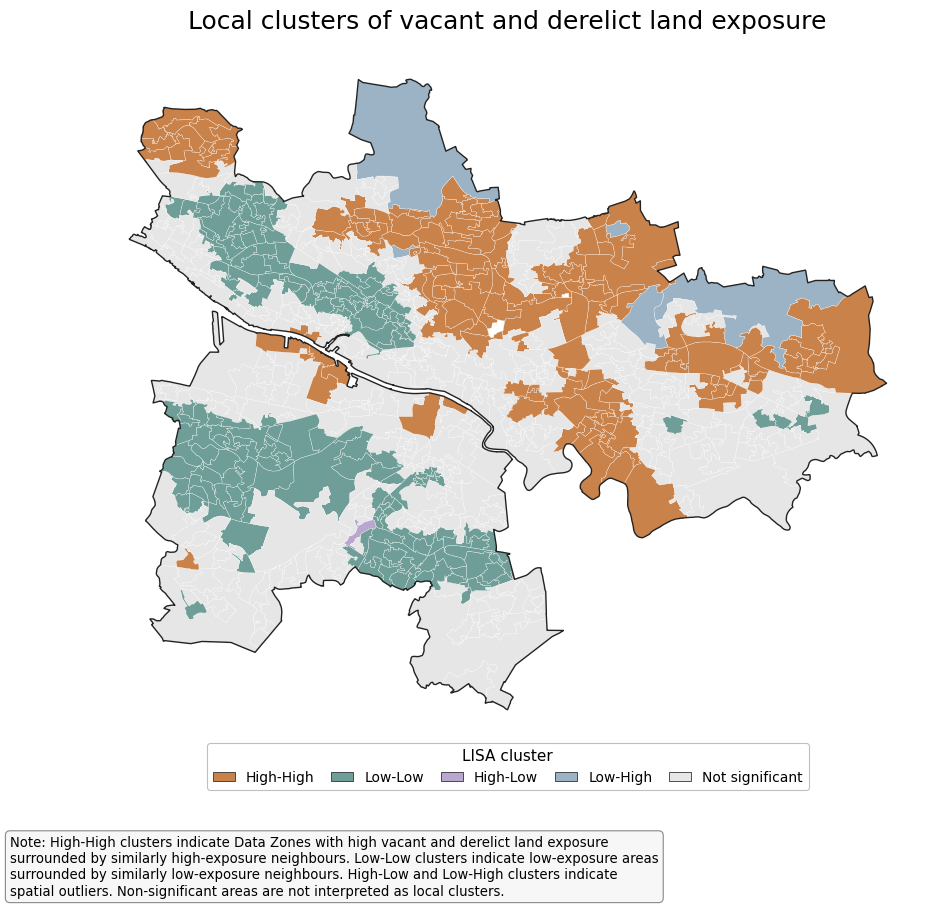

In [27]:
# Map local clusters of VDL exposure
vdl_lisa_colors = {
    "High-High": "#C9824A",
    "Low-Low": "#6E9E97",
    "High-Low": "#B9A7D0",
    "Low-High": "#9BB3C5",
    "Not significant": "#E6E6E6"
}

fig, ax = plt.subplots(figsize=(11, 9.5))

model_gdf.plot(
    ax=ax,
    color=model_gdf["vdl_lisa_cluster"].map(vdl_lisa_colors),
    edgecolor="white",
    linewidth=0.2
)

glasgow_boundary.boundary.plot(
    ax=ax,
    color="#222222",
    linewidth=1.0
)

ax.set_title(
    "Local clusters of vacant and derelict land exposure",
    fontsize=18,
    pad=14
)

ax.axis("off")

cluster_order = [
    "High-High",
    "Low-Low",
    "High-Low",
    "Low-High",
    "Not significant"
]

legend_patches = [
    mpatches.Patch(
        facecolor=vdl_lisa_colors[c],
        edgecolor="#333333",
        linewidth=0.6,
        label=c
    )
    for c in cluster_order
]

legend = ax.legend(
    handles=legend_patches,
    title="LISA cluster",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=5,
    frameon=True,
    fontsize=10,
    title_fontsize=11,
    columnspacing=1.2,
    handlelength=1.6
)

legend.get_frame().set_edgecolor("#B0B0B0")
legend.get_frame().set_linewidth(0.8)
legend.get_frame().set_facecolor("white")

note_text = (
    "Note: High-High clusters indicate Data Zones with high vacant and derelict land "
    "exposure surrounded by similarly high-exposure neighbours. Low-Low clusters indicate "
    "low-exposure areas surrounded by similarly low-exposure neighbours. High-Low and "
    "Low-High clusters indicate spatial outliers. Non-significant areas are not interpreted "
    "as local clusters."
)

wrapped_note = fill(note_text, width=95)

fig.text(
    0.06, 0.035,
    wrapped_note,
    ha="left",
    va="bottom",
    fontsize=9.5,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="#F7F7F7",
        edgecolor="#888888",
        linewidth=0.8
    )
)

plt.subplots_adjust(bottom=0.20, top=0.93)
plt.show()

In [28]:
# Profile neighbourhood characteristics by LISA cluster

lisa_cluster_profile = (
    model_gdf
    .groupby("vdl_lisa_cluster")
    .agg(
        n_data_zones=("DataZone", "count"),
        median_vdl_area_500m_ha=("vdl_area_500m_ha", "median"),
        mean_log_vdl_area_500m=("log_vdl_area_500m", "mean"),
        mean_income_dep_score=("income_dep_score", "mean"),
        median_income_dep_score=("income_dep_score", "median"),
        mean_no_car_share=("no_car_share", "mean"),
        mean_child_share=("child_share", "mean"),
        mean_older_share=("older_share", "mean"),
        mean_log_pop_density=("log_pop_density", "mean"),
        mean_dist_centre_km=("dist_centre_km", "mean"),
        mean_dist_clyde_km=("dist_clyde_km", "mean")
    )
    .reset_index()
)

lisa_cluster_profile["share_of_data_zones_pct"] = (
    lisa_cluster_profile["n_data_zones"] / len(model_gdf) * 100
)

cluster_order = [
    "High-High",
    "Low-Low",
    "High-Low",
    "Low-High",
    "Not significant"
]

lisa_cluster_profile["order"] = lisa_cluster_profile["vdl_lisa_cluster"].apply(
    lambda x: cluster_order.index(x) if x in cluster_order else 99
)

lisa_cluster_profile = (
    lisa_cluster_profile
    .sort_values("order")
    .drop(columns="order")
    .round(3)
    .reset_index(drop=True)
)

display(lisa_cluster_profile)

,vdl_lisa_cluster,n_data_zones,median_vdl_area_500m_ha,mean_log_vdl_area_500m,mean_income_dep_score,median_income_dep_score,mean_no_car_share,mean_child_share,mean_older_share,mean_log_pop_density,mean_dist_centre_km,mean_dist_clyde_km,share_of_data_zones_pct
0,High-High,150,7.933,2.176,5864.910,6501.5,0.492,0.200,0.137,8.243,4.848,3.058,20.188
1,Low-Low,182,0.000,0.059,3624.280,3765.0,0.329,0.167,0.167,8.695,5.209,2.502,24.495
2,High-Low,1,2.426,1.231,2639.000,2639.0,0.297,0.151,0.167,8.359,5.071,3.891,0.135
3,Low-High,5,0.667,0.435,3412.000,1785.0,0.244,0.253,0.086,6.945,5.593,4.760,0.673
4,Not significant,405,1.157,0.841,4917.519,5656.0,0.443,0.169,0.142,8.706,4.829,2.299,54.509


VDL exposure is highly uneven across Glasgow Data Zones. The mean VDL area within 500m is 2.924 ha, but the median is only 0.960 ha and the maximum reaches 28.550 ha. This confirms that exposure is strongly right-skewed, with a small number of Data Zones experiencing much higher exposure than most neighbourhoods. Derelict land accounts for the largest share of clipped VDL area (56.46%), meaning that the exposure measure captures land associated with physical decline, not only unused vacant land.

The spatial statistics show that this unevenness is strongly clustered. Global Moran’s I is high and significant (I = 0.685, p = 0.001), indicating that high and low VDL exposure are spatially grouped rather than randomly distributed. The LISA results identify 150 high-high Data Zones, representing 20.19% of the modelling dataset, and 182 low-low Data Zones, representing 24.50%. This suggests that VDL exposure forms clustered landscapes of disadvantage and low exposure, rather than isolated sites.

The LISA cluster profile also suggests that high-high exposure areas have higher average income deprivation than low-low areas. It indicates that the spatial concentration of VDL overlaps with neighbourhood disadvantage and therefore motivates the spatial regression analysis in the next section.


### 4.2 Spatial Regression Results

,log_vdl_area_500m,income_dep_score,no_car_share,child_share,older_share,log_pop_density,dist_centre_km,dist_clyde_km
log_vdl_area_500m,1.000,0.399,0.352,0.201,-0.193,-0.181,-0.088,0.087
income_dep_score,0.399,1.000,0.643,0.456,-0.064,-0.033,0.111,0.088
no_car_share,0.352,0.643,1.000,-0.043,-0.363,0.274,-0.391,-0.263
child_share,0.201,0.456,-0.043,1.000,-0.062,-0.159,0.393,0.287
older_share,-0.193,-0.064,-0.363,-0.062,1.000,-0.307,0.337,0.141
log_pop_density,-0.181,-0.033,0.274,-0.159,-0.307,1.000,-0.325,-0.249
dist_centre_km,-0.088,0.111,-0.391,0.393,0.337,-0.325,1.000,0.442
dist_clyde_km,0.087,0.088,-0.263,0.287,0.141,-0.249,0.442,1.000


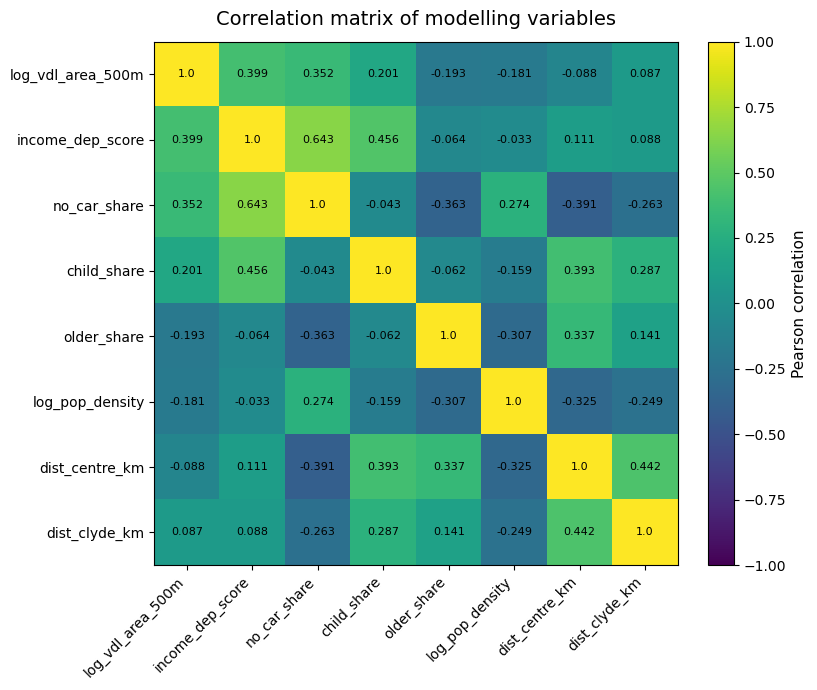

In [29]:
# Correlation matrix for modelling variables

corr_vars = [
    "log_vdl_area_500m",
    "income_dep_score",
    "no_car_share",
    "child_share",
    "older_share",
    "log_pop_density",
    "dist_centre_km",
    "dist_clyde_km"
]

corr_matrix = model_gdf[corr_vars].corr().round(3)

display(corr_matrix)

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    corr_matrix,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(corr_vars)))
ax.set_yticks(range(len(corr_vars)))

ax.set_xticklabels(corr_vars, rotation=45, ha="right")
ax.set_yticklabels(corr_vars)

for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):
        ax.text(
            j,
            i,
            corr_matrix.iloc[i, j],
            ha="center",
            va="center",
            fontsize=8
        )

ax.set_title("Correlation matrix of modelling variables", fontsize=14, pad=12)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson correlation")

plt.tight_layout()
plt.show()

In [30]:
# Variance Inflation Factor check

X_vif = model_gdf[
    [
        "income_dep_score",
        "no_car_share",
        "child_share",
        "older_share",
        "log_pop_density",
        "dist_centre_km",
        "dist_clyde_km"
    ]
].copy()

X_vif = sm.add_constant(X_vif)

vif_table = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_table = vif_table[vif_table["Variable"] != "const"].copy()
vif_table["VIF"] = vif_table["VIF"].round(3)

display(vif_table)

,Variable,VIF
1,income_dep_score,3.729
2,no_car_share,3.857
3,child_share,1.908
4,older_share,1.433
5,log_pop_density,1.236
6,dist_centre_km,1.804
7,dist_clyde_km,1.324


In [31]:
# Standardise explanatory variables for modelling

features_raw = [
    "income_dep_score",
    "no_car_share",
    "child_share",
    "older_share",
    "log_pop_density",
    "dist_centre_km",
    "dist_clyde_km"
]

features_std = [
    "income_dep_score_std",
    "no_car_share_std",
    "child_share_std",
    "older_share_std",
    "log_pop_density_std",
    "dist_centre_km_std",
    "dist_clyde_km_std"
]

scaler = StandardScaler()

model_gdf[features_std] = scaler.fit_transform(
    model_gdf[features_raw]
)

standardisation_check = pd.DataFrame({
    "Variable": features_std,
    "Mean after standardisation": model_gdf[features_std].mean().round(3).values,
    "SD after standardisation": model_gdf[features_std].std(ddof=0).round(3).values
})

display(standardisation_check)

target_var = "log_vdl_area_500m"
features_main = features_std

,Variable,Mean after standardisation,SD after standardisation
0,income_dep_score_std,-0.0,1.0
1,no_car_share_std,0.0,1.0
2,child_share_std,0.0,1.0
3,older_share_std,-0.0,1.0
4,log_pop_density_std,0.0,1.0
5,dist_centre_km_std,0.0,1.0
6,dist_clyde_km_std,-0.0,1.0


In [32]:
# OLS baseline model for VDL exposure using standardised predictors

y_ols = model_gdf[target_var]

X_ols = model_gdf[features_main]
X_ols = sm.add_constant(X_ols)

ols_model = sm.OLS(y_ols, X_ols).fit(cov_type="HC1")

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:      log_vdl_area_500m   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     45.49
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           1.44e-53
Time:                        02:21:07   Log-Likelihood:                -855.69
No. Observations:                 743   AIC:                             1727.
Df Residuals:                     735   BIC:                             1764.
Df Model:                           7                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.9168 

In [33]:
# Moran's I for OLS residuals

model_gdf["ols_residual"] = ols_model.resid

np.random.seed(RANDOM_SEED)

moran_ols_resid = Moran(
    model_gdf["ols_residual"].values,
    w,
    permutations=999
)

print("Global Moran's I for OLS residuals")
print("Moran's I:", round(moran_ols_resid.I, 4))
print("Expected I:", round(moran_ols_resid.EI, 4))
print("p-value:", round(moran_ols_resid.p_sim, 4))

Global Moran's I for OLS residuals
Moran's I: 0.5078
Expected I: -0.0013
p-value: 0.001


In [34]:
# Spatial dependence diagnostics for model selection

y_sp_diag = model_gdf[[target_var]].values
X_sp_diag = model_gdf[features_main].values

ols_spreg_diag = spreg.OLS(
    y_sp_diag,
    X_sp_diag,
    w=w,
    spat_diag=True,
    moran=True,
    name_y=target_var,
    name_x=features_main,
    name_w="Queen contiguity"
)

lm_results = pd.DataFrame({
    "Test": [
        "LM lag",
        "Robust LM lag",
        "LM error",
        "Robust LM error"
    ],
    "Statistic": [
        ols_spreg_diag.lm_lag[0],
        ols_spreg_diag.rlm_lag[0],
        ols_spreg_diag.lm_error[0],
        ols_spreg_diag.rlm_error[0]
    ],
    "p-value": [
        ols_spreg_diag.lm_lag[1],
        ols_spreg_diag.rlm_lag[1],
        ols_spreg_diag.lm_error[1],
        ols_spreg_diag.rlm_error[1]
    ]
})

lm_results["Significant at 5%"] = lm_results["p-value"] < 0.05

display(
    lm_results.style.format({
        "Statistic": "{:.3f}",
        "p-value": "{:.4f}"
    })
)

,Test,Statistic,p-value,Significant at 5%
0,LM lag,628.973,0.0000,True
1,Robust LM lag,109.443,0.0000,True
2,LM error,520.429,0.0000,True
3,Robust LM error,0.898,0.3433,False


In [35]:
# Spatial regression models using standardised predictors

y_sp = model_gdf[[target_var]].values
X_sp = model_gdf[features_main].values

sp_var_names = features_main

slm_model = ML_Lag(
    y_sp,
    X_sp,
    w=w,
    name_y=target_var,
    name_x=sp_var_names,
    name_w="Queen contiguity"
)

sem_model = ML_Error(
    y_sp,
    X_sp,
    w=w,
    name_y=target_var,
    name_x=sp_var_names,
    name_w="Queen contiguity"
)

print("Spatial Lag Model")
print(slm_model.summary)

print("\nSpatial Error Model")
print(sem_model.summary)

ML_Lag
ML_Error
Spatial Lag Model
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :Queen contiguity
Dependent Variable  :log_vdl_area_500m                Number of Observations:         743
Mean dependent var  :      0.9168                Number of Variables   :           9
S.D. dependent var  :      0.9036                Degrees of Freedom    :         734
Pseudo R-squared    :      0.7308
Spatial Pseudo R-squared:  0.3545
Log likelihood      :   -567.6594
Sigma-square ML     :      0.2266                Akaike info criterion :    1153.319
S.E of regression   :      0.4760                Schwarz criterion     :    1194.815

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-

In [36]:
# Compare OLS, Spatial Lag Model and Spatial Error Model

model_comparison = pd.DataFrame([
    {
        "Model": "OLS",
        "Log likelihood": ols_model.llf,
        "AIC": ols_model.aic,
        "BIC": ols_model.bic,
        "Spatial parameter": np.nan
    },
    {
        "Model": "Spatial Lag Model",
        "Log likelihood": slm_model.logll,
        "AIC": slm_model.aic,
        "BIC": slm_model.schwarz,
        "Spatial parameter": slm_model.rho
    },
    {
        "Model": "Spatial Error Model",
        "Log likelihood": sem_model.logll,
        "AIC": sem_model.aic,
        "BIC": sem_model.schwarz,
        "Spatial parameter": sem_model.lam
    }
]).round(4)

display(model_comparison)

,Model,Log likelihood,AIC,BIC,Spatial parameter
0,OLS,-855.6940,1727.3879,1764.2735,NaN
1,Spatial Lag Model,-567.6594,1153.3188,1194.8150,0.8221
2,Spatial Error Model,-580.5673,1177.1346,1214.0202,0.8797


In [37]:
# Moran's I for spatial model residuals

# OLS residuals
ols_resid = np.asarray(ols_model.resid).reshape(-1)

# Spatial Lag Model residuals
slm_resid = np.asarray(slm_model.u).reshape(-1)

# Spatial Error Model filtered residuals
# For ML_Error, e_filtered should be used to assess whether spatial autocorrelation
# remains after the spatial error process has been filtered out.
sem_resid = np.asarray(sem_model.e_filtered).reshape(-1)

np.random.seed(RANDOM_SEED)
moran_ols_resid = Moran(
    ols_resid,
    w,
    permutations=999
)

np.random.seed(RANDOM_SEED)
moran_slm_resid = Moran(
    slm_resid,
    w,
    permutations=999
)

np.random.seed(RANDOM_SEED)
moran_sem_resid = Moran(
    sem_resid,
    w,
    permutations=999
)

residual_moran_table = pd.DataFrame({
    "Model": [
        "OLS",
        "Spatial Lag Model",
        "Spatial Error Model"
    ],
    "Residual Moran's I": [
        moran_ols_resid.I,
        moran_slm_resid.I,
        moran_sem_resid.I
    ],
    "p-value": [
        moran_ols_resid.p_sim,
        moran_slm_resid.p_sim,
        moran_sem_resid.p_sim
    ]
}).round(4)

display(residual_moran_table)

,Model,Residual Moran's I,p-value
0,OLS,0.5078,0.001
1,Spatial Lag Model,0.0055,0.362
2,Spatial Error Model,0.0044,0.382


In [38]:
# Clean coefficient table for the selected Spatial Lag Model

slm_variable_names = [
    "CONSTANT"
] + features_main + [
    "W_log_vdl_area_500m"
]

slm_coef_table = pd.DataFrame({
    "Variable": slm_variable_names,
    "Coefficient": np.asarray(slm_model.betas).reshape(-1),
    "Std. Error": np.asarray(slm_model.std_err).reshape(-1),
    "z-statistic": np.asarray(slm_model.z_stat)[:, 0],
    "p-value": np.asarray(slm_model.z_stat)[:, 1]
})

slm_coef_table["Significance"] = pd.cut(
    slm_coef_table["p-value"],
    bins=[-np.inf, 0.001, 0.01, 0.05, 0.1, np.inf],
    labels=["***", "**", "*", ".", ""]
)

display(
    slm_coef_table.round({
        "Coefficient": 4,
        "Std. Error": 4,
        "z-statistic": 3,
        "p-value": 4
    })
)

,Variable,Coefficient,Std. Error,z-statistic,p-value,Significance
0,CONSTANT,0.1597,0.0273,5.846,0.0000,***
1,income_dep_score_std,0.1210,0.0341,3.548,0.0004,***
2,no_car_share_std,0.0107,0.0343,0.313,0.7543,
3,child_share_std,-0.0055,0.0242,-0.226,0.8214,
4,older_share_std,-0.0632,0.0210,-3.011,0.0026,**
5,log_pop_density_std,-0.0740,0.0196,-3.766,0.0002,***
6,dist_centre_km_std,-0.0232,0.0236,-0.979,0.3274,
7,dist_clyde_km_std,0.0051,0.0202,0.250,0.8025,
8,W_log_vdl_area_500m,0.8221,0.0217,37.822,0.0000,***


The OLS model explains 28.1% of variation in log VDL exposure, but its residuals remain strongly spatially autocorrelated (Moran's I = 0.508, p = 0.001). This means that a non-spatial model leaves substantial spatial structure unexplained. The LM diagnostics support a spatial lag specification: the Robust LM-lag test is significant (109.443, p < 0.001), while the Robust LM-error test is not significant (0.898, p = 0.343).

The Spatial Lag Model is therefore retained as the preferred model. It has a lower AIC than the Spatial Error Model (1153.319 vs 1177.135) and removes residual spatial autocorrelation (Moran's I = 0.006, p = 0.362). The spatial lag coefficient is large and significant (ρ = 0.822, p < 0.001), showing that VDL exposure in one Data Zone is strongly related to exposure in neighbouring Data Zones.

Income deprivation remains positively associated with VDL exposure in the SLM (β = 0.121, p < 0.001). This is the key regression finding: the deprivation association persists even after spatial dependence is modelled. Older population share (β = -0.063, p = 0.003) and log population density (β = -0.074, p < 0.001) are negatively associated with exposure, suggesting that higher VDL exposure is more characteristic of lower-density and less older-resident neighbourhood contexts. In contrast, no-car household share and the distance variables are no longer significant, suggesting that their OLS associations are partly absorbed by the spatial structure of VDL exposure.


### 4.3 Random Forest Regression and SHAP Interpretation

In [39]:
# Random Forest regression for continuous VDL exposure

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

rf_features = features_raw
X_rf = model_gdf[rf_features].copy()
y_rf = model_gdf["log_vdl_area_500m"].copy()

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.2,
    random_state=42
)

rf_reg = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train_rf, y_train_rf)

y_pred_rf = rf_reg.predict(X_test_rf)

rf_reg_results = pd.DataFrame({
    "Model": ["Random Forest regressor"],
    "N_train": [len(X_train_rf)],
    "N_test": [len(X_test_rf)],
    "R2": [r2_score(y_test_rf, y_pred_rf)],
    "MAE": [mean_absolute_error(y_test_rf, y_pred_rf)],
    "RMSE": [np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))]
}).round(3)

display(rf_reg_results)

,Model,N_train,N_test,R2,MAE,RMSE
0,Random Forest regressor,594,149,0.461,0.545,0.685


In [40]:
# Baseline comparison and random cross-validation for RF regression

baseline_pred = np.repeat(y_train_rf.mean(), len(y_test_rf))

baseline_results = pd.DataFrame({
    "Model": [
        "Mean baseline",
        "Random Forest regressor"
    ],
    "R2": [
        r2_score(y_test_rf, baseline_pred),
        r2_score(y_test_rf, y_pred_rf)
    ],
    "MAE": [
        mean_absolute_error(y_test_rf, baseline_pred),
        mean_absolute_error(y_test_rf, y_pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_rf, baseline_pred)),
        np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
    ]
}).round(3)

display(baseline_results)

rf_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error"
}

rf_cv_results = cross_validate(
    rf_reg,
    X_rf,
    y_rf,
    cv=rf_cv,
    scoring=cv_scoring,
    n_jobs=-1
)

# Convert negative scores back to positive error metrics
rf_cv_mae = -rf_cv_results["test_mae"]
rf_cv_rmse = np.sqrt(-rf_cv_results["test_mse"])

rf_cv_summary = pd.DataFrame({
    "Metric": [
        "R2",
        "MAE",
        "RMSE"
    ],
    "Mean": [
        rf_cv_results["test_r2"].mean(),
        rf_cv_mae.mean(),
        rf_cv_rmse.mean()
    ],
    "Std": [
        rf_cv_results["test_r2"].std(),
        rf_cv_mae.std(),
        rf_cv_rmse.std()
    ]
}).round(3)

display(rf_cv_summary)

,Model,R2,MAE,RMSE
0,Mean baseline,-0.000,0.810,0.933
1,Random Forest regressor,0.461,0.545,0.685


,Metric,Mean,Std
0,R2,0.417,0.050
1,MAE,0.555,0.029
2,RMSE,0.688,0.031


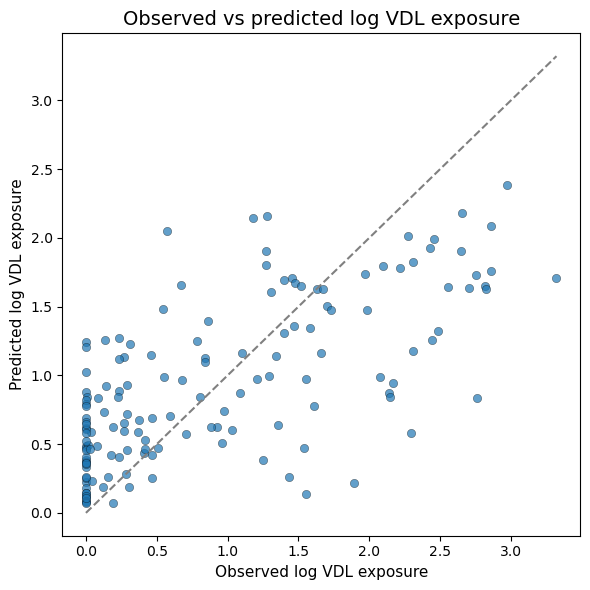

In [41]:
# Observed vs predicted VDL exposure for RF regression

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    y_test_rf,
    y_pred_rf,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.3
)

min_val = min(y_test_rf.min(), y_pred_rf.min())
max_val = max(y_test_rf.max(), y_pred_rf.max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="grey",
    linewidth=1.5
)

ax.set_title("Observed vs predicted log VDL exposure")
ax.set_xlabel("Observed log VDL exposure")
ax.set_ylabel("Predicted log VDL exposure")

plt.tight_layout()
plt.show()

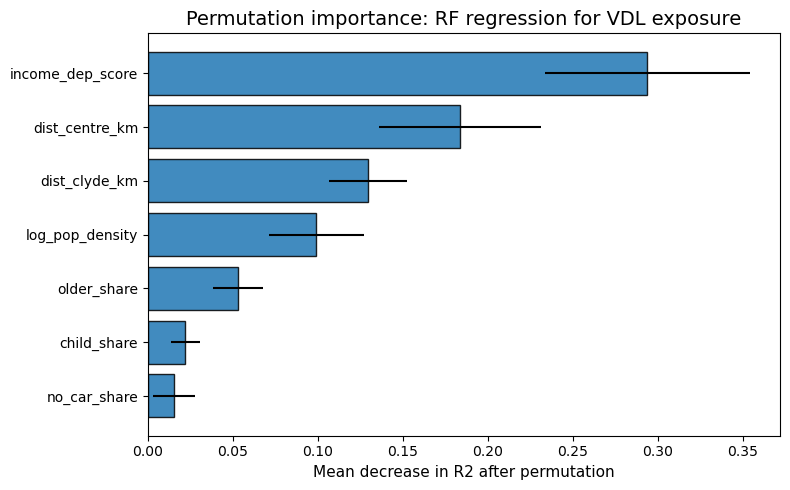

,Variable,Mean decrease in R2,Std
0,income_dep_score,0.2938,0.0604
5,dist_centre_km,0.1835,0.0477
6,dist_clyde_km,0.1297,0.0229
4,log_pop_density,0.0990,0.0279
3,older_share,0.0532,0.0147
2,child_share,0.0220,0.0084
1,no_car_share,0.0153,0.0125


In [42]:
# Permutation importance for RF regression

from sklearn.inspection import permutation_importance

perm_reg = permutation_importance(
    rf_reg,
    X_test_rf,
    y_test_rf,
    n_repeats=30,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

perm_reg_importance = pd.DataFrame({
    "Variable": rf_features,
    "Mean decrease in R2": perm_reg.importances_mean,
    "Std": perm_reg.importances_std
}).sort_values(
    "Mean decrease in R2",
    ascending=True
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    perm_reg_importance["Variable"],
    perm_reg_importance["Mean decrease in R2"],
    xerr=perm_reg_importance["Std"],
    edgecolor="black",
    alpha=0.85
)

ax.set_title("Permutation importance: RF regression for VDL exposure")
ax.set_xlabel("Mean decrease in R2 after permutation")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

display(
    perm_reg_importance
    .sort_values("Mean decrease in R2", ascending=False)
    .round(4)
)

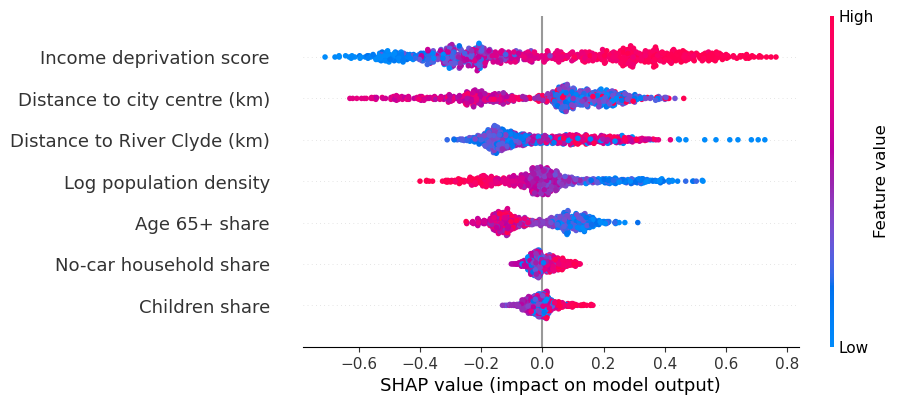

In [43]:
# SHAP analysis for RF regression

import shap

raw_label_map = {
    "income_dep_score": "Income deprivation score",
    "no_car_share": "No-car household share",
    "child_share": "Children share",
    "older_share": "Age 65+ share",
    "log_pop_density": "Log population density",
    "dist_centre_km": "Distance to city centre (km)",
    "dist_clyde_km": "Distance to River Clyde (km)"
}

X_rf_labelled = X_rf.rename(columns=raw_label_map)

# Refit model using labelled columns so SHAP plots show readable names
rf_reg_shap = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_reg_shap.fit(X_rf_labelled, y_rf)

explainer = shap.TreeExplainer(rf_reg_shap)
shap_values = explainer(X_rf_labelled)

shap.plots.beeswarm(
    shap_values,
    max_display=7
)

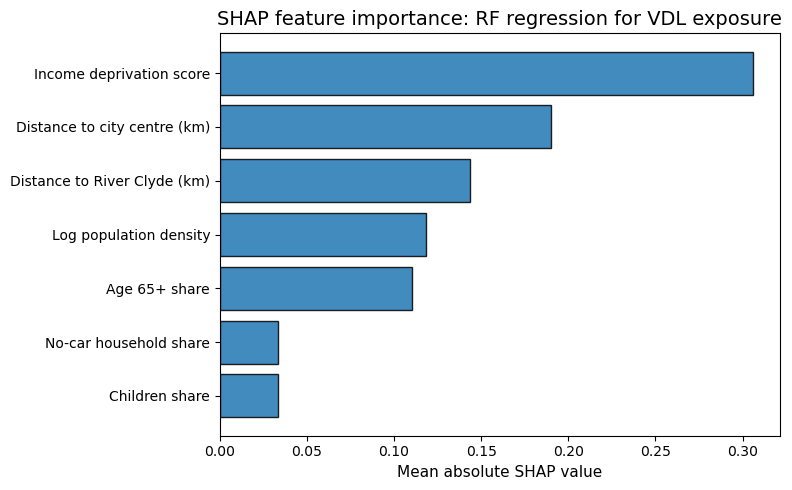

,Variable,Mean absolute SHAP value
0,Income deprivation score,0.3062
5,Distance to city centre (km),0.1901
6,Distance to River Clyde (km),0.1436
4,Log population density,0.1185
3,Age 65+ share,0.1100
1,No-car household share,0.0335
2,Children share,0.0334


In [44]:
# Mean absolute SHAP values for RF regression

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Variable": X_rf_labelled.columns,
    "Mean absolute SHAP value": mean_abs_shap
}).sort_values(
    "Mean absolute SHAP value",
    ascending=True
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    shap_importance["Variable"],
    shap_importance["Mean absolute SHAP value"],
    edgecolor="black",
    alpha=0.85
)

ax.set_title("SHAP feature importance: RF regression for VDL exposure")
ax.set_xlabel("Mean absolute SHAP value")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

display(
    shap_importance
    .sort_values("Mean absolute SHAP value", ascending=False)
    .round(4)
)

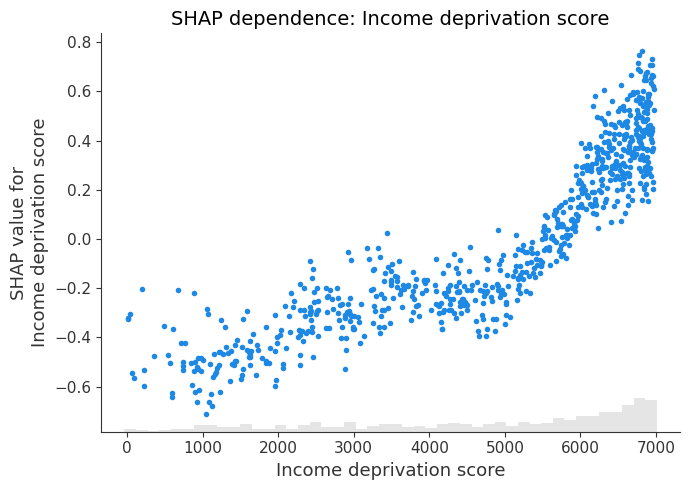

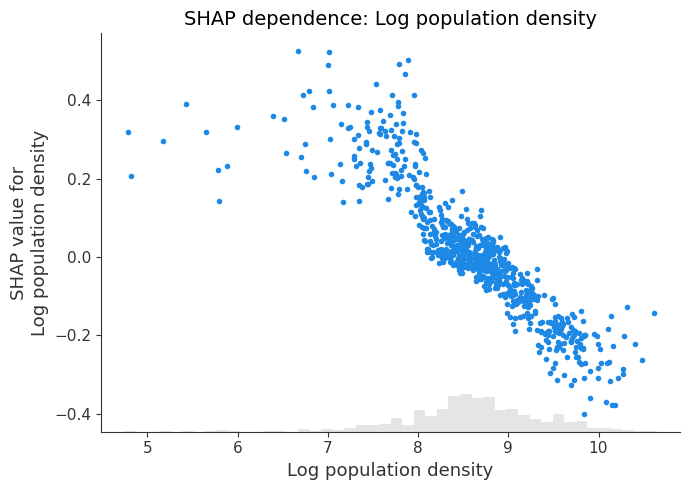

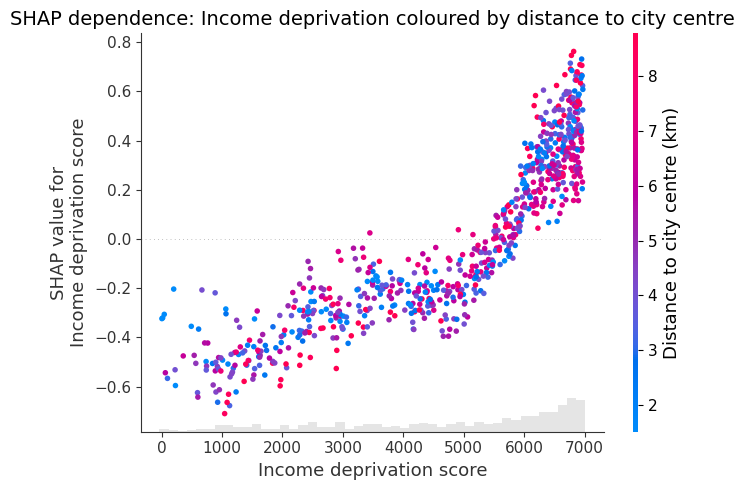

In [45]:
# SHAP dependence plots for key variables

dependence_plots = [
    {
        "feature": "Income deprivation score",
        "title": "SHAP dependence: Income deprivation score"
    },
    {
        "feature": "Log population density",
        "title": "SHAP dependence: Log population density"
    },
    {
        "feature": "Income deprivation score",
        "color": "Distance to city centre (km)",
        "title": "SHAP dependence: Income deprivation coloured by distance to city centre"
    }
]

for plot in dependence_plots:
    feature = plot["feature"]
    color_feature = plot.get("color", None)

    if color_feature is None:
        shap.plots.scatter(
            shap_values[:, feature],
            show=False
        )
    else:
        shap.plots.scatter(
            shap_values[:, feature],
            color=shap_values[:, color_feature],
            show=False
        )

    fig = plt.gcf()
    fig.set_size_inches(7, 5)
    ax = plt.gca()
    ax.set_title(plot["title"])

    plt.tight_layout()
    plt.show()

The Random Forest model shows moderate predictive performance, with a test R² of 0.461 and a random five-fold cross-validation R² of 0.417. The model performs better than a mean baseline, but the observed-versus-predicted plot shows clear limits: the highest exposure Data Zones are generally underpredicted, while some zero-exposure areas are overpredicted. This indicates that the predictors capture broad neighbourhood patterns but not all extreme local VDL concentrations.

The most important result is the consistency between permutation importance and SHAP values. Both rank income deprivation as the strongest predictor. This supports the SLM result and strengthens the interpretation that VDL exposure is socially uneven. However, the RF results also show that deprivation is not the only relevant dimension. Distance to the city centre, distance to the River Clyde, population density and older population share also contribute strongly to prediction.

SHAP dependence plots show that income deprivation generally pushes predicted exposure upward, while urban-structure variables have less uniform effects. This indicates that the relationship is not fully linear or additive, but the main message remains consistent: deprivation is the dominant predictor, while spatial urban structure shapes where high exposure is concentrated.


### 4.4 Validation and Robustness Checks

In [46]:
# 4.4 Spatial-block validation for the RF regression
if "Intermediate_Zone" not in model_gdf.columns:
    model_gdf = model_gdf.merge(
        analysis_gdf[["DataZone", "Intermediate_Zone"]], on="DataZone", how="left")

groups = model_gdf["Intermediate_Zone"]
spatial_cv = GroupKFold(n_splits=5)

spatial_reg_results = cross_validate(
    rf_reg,          
    model_gdf[features_raw], 
    model_gdf["log_vdl_area_500m"], 
    cv=spatial_cv, groups=groups,
    scoring={"r2": "r2", "mae": "neg_mean_absolute_error"},
    n_jobs=-1
)

spatial_vs_random = pd.DataFrame({
    "Validation": ["Random 5-fold", "Spatial block (Intermediate Zone)"],
    "R2 mean":  [rf_cv_results["test_r2"].mean(),  spatial_reg_results["test_r2"].mean()],
    "R2 std":   [rf_cv_results["test_r2"].std(),   spatial_reg_results["test_r2"].std()],
    "MAE mean": [-rf_cv_results["test_mae"].mean(), -spatial_reg_results["test_mae"].mean()],
}).round(3)
display(spatial_vs_random)

,Validation,R2 mean,R2 std,MAE mean
0,Random 5-fold,0.417,0.050,0.555
1,Spatial block (Intermediate Zone),0.312,0.076,0.598


In [47]:
# Derelict-only exposure robustness check

# Select derelict land polygons from the same VDL layer used for 500m buffer exposure
derelict_for_buffer = vdl_for_buffer[
    vdl_for_buffer["site_type"] == "Derelict"
].copy()

print("Derelict land polygons used for 500m buffer exposure:", derelict_for_buffer.shape[0])

dz_points_derelict = model_gdf[
    [
        "DataZone",
        "geometry"
    ]
].copy()

dz_points_derelict["geometry"] = dz_points_derelict.geometry.centroid

dz_buffers_500m_derelict = dz_points_derelict.copy()
dz_buffers_500m_derelict["geometry"] = dz_buffers_500m_derelict.geometry.buffer(500)

derelict_buffer_intersections = gpd.overlay(
    dz_buffers_500m_derelict,
    derelict_for_buffer[
        [
            "site_code",
            "geometry"
        ]
    ],
    how="intersection"
)

derelict_buffer_intersections["derelict_area_500m_ha"] = (
    derelict_buffer_intersections.geometry.area / 10000
)

derelict_500m_summary = (
    derelict_buffer_intersections
    .groupby("DataZone")
    .agg(
        derelict_area_500m_ha=("derelict_area_500m_ha", "sum"),
        derelict_site_count_500m=("site_code", "nunique")
    )
    .reset_index()
)

model_gdf = model_gdf.drop(
    columns=[
        "derelict_area_500m_ha",
        "derelict_site_count_500m",
        "log_derelict_area_500m"
    ],
    errors="ignore"
)

model_gdf = model_gdf.merge(
    derelict_500m_summary,
    on="DataZone",
    how="left"
)

model_gdf["derelict_area_500m_ha"] = model_gdf["derelict_area_500m_ha"].fillna(0)
model_gdf["derelict_site_count_500m"] = (
    model_gdf["derelict_site_count_500m"]
    .fillna(0)
    .astype(int)
)

model_gdf["log_derelict_area_500m"] = np.log1p(
    model_gdf["derelict_area_500m_ha"]
)

derelict_corr = model_gdf[
    [
        "log_vdl_area_500m",
        "log_derelict_area_500m"
    ]
].corr().iloc[0, 1]

np.random.seed(RANDOM_SEED)

moran_derelict = Moran(
    model_gdf["log_derelict_area_500m"].values,
    w,
    permutations=999
)

derelict_robustness_summary = pd.DataFrame({
    "Measure": [
        "Data Zones with derelict-only exposure within 500m",
        "Maximum derelict-only area within 500m (ha)",
        "Correlation with combined log VDL exposure",
        "Global Moran's I for derelict-only exposure",
        "Moran's I p-value"
    ],
    "Value": [
        int((model_gdf["derelict_area_500m_ha"] > 0).sum()),
        round(model_gdf["derelict_area_500m_ha"].max(), 3),
        round(derelict_corr, 3),
        round(moran_derelict.I, 3),
        round(moran_derelict.p_sim, 3)
    ]
})

display(derelict_robustness_summary)

Derelict land polygons used for 500m buffer exposure: 262


,Measure,Value
0,Data Zones with derelict-only exposure within ...,391.000
1,Maximum derelict-only area within 500m (ha),27.206
2,Correlation with combined log VDL exposure,0.820
3,Global Moran's I for derelict-only exposure,0.598
4,Moran's I p-value,0.001


The validation results show that Random Forest performance declines when spatial dependence is considered more strictly. Random five-fold cross-validation gives a mean R² of 0.417, while spatial-block validation reduces the mean R² to 0.312. The MAE also increases from 0.555 to 0.598. This indicates that part of the RF model's performance comes from spatially clustered information. In other words, the model performs better when nearby Data Zones can appear across training and test folds, but prediction becomes weaker when the test areas are more spatially separated. 

The derelict-only robustness check supports the main exposure measure. Derelict-only exposure is strongly correlated with the combined VDL exposure measure (r = 0.820), and it also shows significant positive spatial autocorrelation (Moran's I = 0.598, p = 0.001). This means that the main spatial pattern is not driven only by ordinary vacant land. 


## 5. Discussion

### 5.1 Key Findings

VDL exposure in Glasgow is both spatially clustered and socially uneven. High exposure is not distributed as isolated sites, but concentrated in connected neighbourhood landscapes (Moran's I = 0.685). These high-exposure clusters also overlap with areas of higher income deprivation, providing descriptive evidence of an environmental justice pattern.

This relationship remains after spatial dependence is modelled. In the Spatial Lag Model, income deprivation is still positively associated with VDL exposure (β = 0.121, p < 0.001), while the spatial lag coefficient is large (ρ = 0.822). The effect decomposition is especially important: the total deprivation effect is 0.680, of which the indirect (spillover) component (0.559) makes up the majority, suggesting that the deprivation exposure relationship operates mainly across connected clusters of neighbouring Data Zones rather than only within individual zones. By contrast, no-car share and distance variables lose significance, indicating that some OLS associations were absorbed by the spatial structure of VDL exposure.

The Random Forest and SHAP results support this interpretation from a different perspective. Income deprivation is the strongest predictor, while distance to the city centre, distance to the River Clyde and population density also contribute to prediction. This suggests that VDL exposure is shaped by both social disadvantage and Glasgow's urban structure. The derelict-only robustness check confirms that the clustered pattern is not simply produced by combining different VDL categories.


### 5.2 Implications

The findings suggest that VDL regeneration should target clustered high-exposure areas rather than isolated sites. Since the deprivation effect is largely indirect, policy responses should consider neighbouring Data Zones as connected landscapes of exposure. A site-by-site approach may improve individual parcels but leave the wider exposure landscape unchanged if nearby derelict sites remain untreated. The LISA clusters can therefore help identify priority areas for land remediation and regeneration funding.

The results also support an environmental justice framing. Derelict land forms the largest share of VDL exposure, and its concentration in more deprived areas means that environmental and socioeconomic disadvantage overlap. Therefore, remediation, temporary greening and community reuse should prioritise derelict sites within deprived clusters, rather than treating VDL only as vacant development capacity.

### 5.3 Limitations

First, the results are neighbourhood-level associations, not causal effects. The analysis is cross-sectional, and population density may be partly endogenous because vacant land can itself reduce residential density. Second, income deprivation is measured through the SIMD income-domain rank rather than a continuous rate. Finally, the exposure measure has spatial limitations. The use of Data Zones and centroid-based 500m buffers may introduce MAUP and exposure-measurement bias. Overlapping buffers may also increase measured spatial dependence.

Future work could use population-weighted centroids, test alternative buffer distances, and incorporate longitudinal VDL records to examine whether regeneration reduces exposure over time.


## 6. Conclusion

Vacant and derelict land in Glasgow is unevenly distributed across the city and concentrated in particular neighbourhood clusters. High exposure is therefore not a random or isolated land-use pattern, but a connected neighbourhood-level burden. These high-exposure landscapes also overlap with income deprivation, showing that derelict land is part of a wider geography of environmental and socioeconomic disadvantage. At the same time, population density, distance to the city centre and distance to the River Clyde show that VDL exposure is also related to Glasgow’s wider urban structure and post-industrial geography.

Overall, VDL should be treated as a neighbourhood-level environmental burden, not only as unused land. Regeneration should prioritise clustered high-exposure areas where derelict land and deprivation coincide, so that land remediation contributes to fairer urban regeneration in Glasgow.


## References

Anselin, L. 1988. *Spatial econometrics: methods and models*. Dordrecht: Kluwer Academic Publishers.

Anselin, L. 1995. Local indicators of spatial association—LISA. *Geographical Analysis*. **27**(2), pp.93–115. Available from: https://doi.org/10.1111/j.1538-4632.1995.tb00338.x

Anselin, L., Bera, A.K., Florax, R. and Yoon, M.J. 1996. Simple diagnostic tests for spatial dependence. *Regional Science and Urban Economics*. **26**(1), pp.77–104. Available from: https://doi.org/10.1016/0166-0462(95)02111-6

Bivand, R.S., Pebesma, E. and Gómez-Rubio, V. 2013. *Applied Spatial Data Analysis with R*. 2nd ed. New York: Springer.

Breiman, L. 2001. Random forests. *Machine Learning*. **45**, pp.5–32.

Foo, K., Martin, D., Wool, C. and Polsky, C. 2013. The production of urban vacant land: relational placemaking in Boston, MA neighborhoods. *Cities*. **35**, pp.156–163. Available from: https://doi.org/10.1016/j.cities.2013.06.012

Lundberg, S.M. and Lee, S.-I. 2017. A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems*. **30**.

Maantay, J. and Maroko, A. 2015. ‘At-risk’ places: inequities in the distribution of environmental stressors and prescription rates of mental health medications in Glasgow, Scotland. *Environmental Research Letters*. **10**(11), 115003. Available from: https://doi.org/10.1088/1748-9326/10/11/115003

Mitchell, R. and Popham, F. 2008. Effect of exposure to natural environment on health inequalities: an observational population study. *The Lancet*. **372**(9650), pp.1655–1660. Available from: https://doi.org/10.1016/S0140-6736(08)61689-X

Moran, P.A.P. 1950. Notes on continuous stochastic phenomena. *Biometrika*. **37**(1/2), pp.17–23.

Roberts, D.R., Bahn, V., Ciuti, S., Boyce, M.S., Elith, J., Guillera-Arroita, G., Hauenstein, S., Lahoz-Monfort, J.J., Schröder, B., Thuiller, W., Warton, D.I., Wintle, B.A., Hartig, F. and Dormann, C.F. 2017. Cross-validation strategies for data with temporal, spatial, hierarchical, or phylogenetic structure. *Ecography*. **40**(8), pp.913–929. Available from: https://doi.org/10.1111/ecog.02881

Scottish Government. 2012. *Scottish Vacant and Derelict Land Survey 2011*. [Online]. [Accessed 9 June 2026]. Available from: https://www.gov.scot/publications/scottish-vacant-derelict-land-survey-2011/

Walker, G. 2012. *Environmental justice: concepts, evidence and politics*. London: Routledge.


## Data Sources

National Records of Scotland. 2024. *Scotland’s Census 2022: cars or vans, number of*. [Online]. [Accessed 9 June 2026]. Available from: https://www.scotlandscensus.gov.uk/metadata/cars-or-vans-number-of/

National Records of Scotland. 2024. *Scotland’s Census 2022: age*. [Online]. [Accessed 9 June 2026]. Available from: https://www.scotlandscensus.gov.uk/metadata/age/

Improvement Service. 2025. *Vacant and Derelict Land - Scotland*. [Online]. [Accessed 9 June 2026]. Available from: https://data.spatialhub.scot/dataset/vacant_and_derelict_land-is

Ordnance Survey. 2024. *OS Open Rivers*. [Online]. [Accessed 9 June 2026]. Available from: https://www.ordnancesurvey.co.uk/products/os-open-rivers

Scottish Government. 2014. *Data Zone Boundaries 2011*. [Online]. [Accessed 9 June 2026]. Available from: https://spatialdata.gov.scot/geonetwork/srv/eng/catalog.search#/metadata/7d3e8709-98fa-4d71-867c-d5c8293823f2

Scottish Government. 2020. *Scottish Index of Multiple Deprivation 2020*. [Online]. [Accessed 9 June 2026]. Available from: https://www.gov.scot/simd



#### Word Count
**2704**

#### AI Used Declaration

Generative AI (ChatGPT) was used to help developing some parts of the codes, and also help checking the sentences and grammer. All the design and analysis were developed by the author.